# 1. Consulta: Índices adicionales a la PSD para clasificación BCI
---

## Introducción

Los sistemas BCI basados en imaginación motora requieren características que capturen
la complejidad de la señal EEG más allá de la densidad espectral de potencia. La PSD
cuantifica la distribución de energía en el espectro pero promedia sobre toda la ventana
temporal, perdiendo información sobre la dinámica no estacionaria del EEG. La literatura
reciente identifica tres familias de índices complementarios que mejoran consistentemente
la clasificación de estados motores: características en dominio tiempo-frecuencia
(energía wavelet), asimetría hemisférica de potencia (Brain Symmetry Index) y descriptores
temporales (parámetros de Hjorth) [1][2][3].

## Índice 1: Energía Wavelet por Paquetes (Daubechies db4)

### Fundamento teórico

La transformada wavelet por paquetes (WPT) descompone la señal en coeficientes
localizados simultáneamente en tiempo y frecuencia, usando funciones base compactas
llamadas wavelets madre. A diferencia de la FFT, que usa senos y cosenos de duración
infinita, la wavelet captura cómo varía la potencia a lo largo del tiempo dentro de
cada época, siendo más adecuada para señales no estacionarias como el EEG [1].

A diferencia de la DWT estándar, que solo descompone la rama de aproximación en
cada nivel, la WPT descompone **tanto la rama de aproximación como la de detalle**,
generando un árbol binario completo. Esto produce una resolución frecuencial uniforme
en todos los nodos de un mismo nivel, permitiendo seleccionar bandas de frecuencia
con mayor precisión que la DWT.

La base Daubechies db4 es seleccionada porque su morfología se aproxima
mejor a los patrones de los potenciales corticales (visto en clase), capturando con
mayor fidelidad los ritmos mu y beta.

Con fs = 160 Hz y nivel de descomposición (L) 5, el ancho de banda por nodo es:

$$\Delta f = \frac{f_s}{2^{L+1}} = \frac{160}{2^6} = 2.5 \text{ Hz}$$

Esto permite alinear los nodos exactamente con las bandas de interés aproximadas. No se elige nivel 6 porque el loop por época se vuelve significativamente más lento por haber el doble de nodos :

| Banda | Rango objetivo | Nodos WPT nivel 5 | Cobertura exacta |
|-------|---------------|-------------------|-----------------|
| Mu    | 8 – 12 Hz     | nodos 3–4         | 7.5 – 12.5 Hz   |
| Beta  | 13 – 30 Hz    | nodos 5–11        | 12.5 – 27.5 Hz  |

La energía relativa de cada banda se calcula como la suma de energías de los nodos
correspondientes, normalizada por la energía total de la época:

$$E_{\text{banda}}^{rel} = \frac{\sum_{n \in \text{nodos banda}} \sum_k c_n[k]^2}{\sum_{n=0}^{2^L - 1} \sum_k c_n[k]^2}$$

donde $c_n[k]$ son los coeficientes del nodo $n$ en el nivel $L=5$.

### Uso en el proyecto

Se extraen las energías relativas de los nodos mu (8–12 Hz) y beta (13–30 Hz) en
C3 y C4. Durante la imaginación motora ocurre ERD contralateral al lado imaginado,
lo que reduce la energía en las bandas mu y beta en el hemisferio opuesto. La energía
wavelet captura este fenómeno con resolución temporal que la PSD no provee [1][2].

### Implementación en Python

```python
def wavelet_energy(epocas, wavelet='db4', level=5, fs=160.0,
                   banda_mu=(8.0, 12.0), banda_beta=(13.0, 30.0)):
    """
    Energía relativa WPT en bandas mu y beta.

    Usa Wavelet Packet Transform (WPT) con base db4 en lugar de DWT estándar
    porque WPT descompone tanto la rama de aproximación como la de detalle,
    generando resolución frecuencial uniforme en todos los nodos del nivel L.

    Con fs=160 Hz y level=5, ancho de banda por nodo = 2.5 Hz:
      Mu   (8–12 Hz)  → nodos 3–4  (centros en 8.75 y 11.25 Hz)
      Beta (13–30 Hz) → nodos 5–11 (centros en 13.75 a 26.25 Hz)

    Nota: pywt.WaveletPacket no soporta procesamiento batch nativo,
    por lo que se usa un bucle sobre épocas. Las operaciones internas
    (np.sum, indexado con mask) están vectorizadas sobre los nodos.

    Parámetros
    ----------
    epocas     : np.ndarray, shape (n_epocas, n_muestras)
    wavelet    : str   — base wavelet (default: 'db4')
    level      : int   — nivel de descomposición (default: 5)
    fs         : float — frecuencia de muestreo (default: 160.0)
    banda_mu   : tuple — (f_low, f_high) banda mu en Hz
    banda_beta : tuple — (f_low, f_high) banda beta en Hz

    Retorna
    -------
    e_mu   : np.ndarray, shape (n_epocas,) — energía relativa banda mu
    e_beta : np.ndarray, shape (n_epocas,) — energía relativa banda beta
    """
    # Ancho de banda por nodo y centros frecuenciales de los 32 nodos
    # Con fs=160 y level=5: bw = 160/64 = 2.5 Hz por nodo
    bw      = fs / (2 ** (level + 1))
    n_nodos = 2 ** level                        # 32 nodos en nivel 5
    centros = (np.arange(n_nodos) + 0.5) * bw  # centro de cada nodo en Hz

    # Máscaras booleanas: True si el centro del nodo cae en la banda
    # mask_mu shape: (32,) True en nodos 3 y 4 (centros 8.75 y 11.25 Hz)
    # mask_beta shape: (32,) True en nodos 5 a 11
    mask_mu   = (centros >= banda_mu[0])   & (centros <= banda_mu[1])
    mask_beta = (centros >= banda_beta[0]) & (centros <= banda_beta[1])

    def _energia_epoca(epoca):
        """Calcula energías relativas mu y beta para una sola época."""
        wp      = pywt.WaveletPacket(data=epoca, wavelet=wavelet,
                                     mode='symmetric', maxlevel=level)
        # get_level con order='freq' ordena nodos de menor a mayor frecuencia
        # energias shape: (32,) — una energía por nodo
        nodos    = wp.get_level(level, order='freq')
        energias = np.array([np.sum(n.data**2) for n in nodos])
        e_total  = np.sum(energias) + 1e-12  # evitar división por cero

        return (np.sum(energias[mask_mu])   / e_total,
                np.sum(energias[mask_beta]) / e_total)

    # List comprehension sobre épocas — más legible que bucle con pre-asignación
    # El bucle es inevitable porque WaveletPacket no soporta batch nativo
    resultados = [_energia_epoca(ep) for ep in epocas]

    # np.array convierte lista de tuplas a array (n_epocas, 2)
    # luego .T separa en dos arrays (n_epocas,) cada uno
    e_mu, e_beta = np.array(resultados).T
    return e_mu, e_beta
```

## Índice 2. Índice de Asimetría de Potencia Hemisférica (Brain Symmetry Index - ASI)
* **Descripción de la medida:** Es una métrica neurofisiológica cuantitativa que evalúa la diferencia de potencia espectral entre canales homólogos ubicados de forma simétrica en ambos hemisferios cerebrales (izquierdo vs. derecho). Su formulación matemática estándar es [2]:

$$ASI = \frac{P_{\text{izq}} - P_{\text{der}}}{P_{\text{izq}} + P_{\text{der}}}$$

* **Uso en los datos del proyecto:** Al iniciar la imaginación motora (IM), las neuronas aumentan su excitabilidad y se despolarizan; al dejar de disparar al unísono, las señales se cancelan entre sí, reduciendo la potencia total (ERD). Según Yu et al. [3], este patrón es asimétrico debido a la organización contralateral: la IM de la mano derecha atenúa la potencia en el canal $C3$ (hemisferio izquierdo), mientras que la de la mano izquierda lo hace en $C4$ (hemisferio derecho). El $ASI$ captura esta diferencia: valores negativos indican activación en $C3$ (mano derecha) y valores positivos indican activación en $C4$ (mano izquierda), optimizando la discriminación de características para el Machine Learning.

### Implementación en Python
```python
def asi(epocas_c3, epocas_c4, banda, fs=160):
    """
    Calcula el Índice de Asimetría Hemisférica (ASI) entre C3 y C4.

    El ASI cuantifica la diferencia relativa de potencia espectral entre
    los hemisferios izquierdo (C3) y derecho (C4) en una banda de frecuencia.
    Debido a la organización contralateral del sistema motor, la imaginación
    de movimiento de la mano derecha genera ERD en C3 (hemisferio izquierdo)
    reduciendo su potencia, mientras que la de la mano izquierda lo hace en C4.

    Interpretación del signo:
      ASI < 0 → mayor activación en C3 → imaginación mano derecha
      ASI > 0 → mayor activación en C4 → imaginación mano izquierda
      ASI ≈ 0 → actividad simétrica    → reposo

    Parámetros
    ----------
    epocas_c3 : np.ndarray, shape (n_epocas, n_muestras)
        Señal temporal filtrada del canal C3 (hemisferio izquierdo)
    epocas_c4 : np.ndarray, shape (n_epocas, n_muestras)
        Señal temporal filtrada del canal C4 (hemisferio derecho)
    banda     : tuple (f_low, f_high) en Hz
        Rango de frecuencias sobre el que se calcula la potencia.
        Usar BANDA_MU=(8,12) o BANDA_BETA=(13,30).
    fs        : float
        Frecuencia de muestreo en Hz (default: 160)

    Retorna
    -------
    asi_vals : np.ndarray, shape (n_epocas,)
        Valor ASI por época. Rango teórico: [-1, 1].
    """
    from scipy.signal import welch

    nperseg = int(2.0 * fs)  # ventana de 2s → resolución frecuencial 0.5 Hz
                              # consistente con nperseg del proyecto 1

    # Welch vectorizado sobre axis=-1 (eje de muestras):
    # procesa las n_epocas simultáneamente sin bucles.
    # psd_c3, psd_c4 shape: (n_epocas, n_freqs)
    freqs, psd_c3 = welch(epocas_c3, fs=fs, nperseg=nperseg,
                          noverlap=nperseg//2, axis=-1)
    _,     psd_c4 = welch(epocas_c4, fs=fs, nperseg=nperseg,
                          noverlap=nperseg//2, axis=-1)

    # Selector booleano de frecuencias dentro de la banda de interés
    # Ejemplo para BANDA_MU=(8,12): True en bins 8–12 Hz, False fuera
    mask = (freqs >= banda[0]) & (freqs <= banda[1])

    # np.trapz vectorizado sobre axis=-1: integra la potencia en la banda
    # para cada época simultáneamente → (n_epocas,)
    p_c3 = np.trapz(psd_c3[:, mask], freqs[mask], axis=-1)
    p_c4 = np.trapz(psd_c4[:, mask], freqs[mask], axis=-1)

    return (p_c3 - p_c4) / (p_c3 + p_c4 + 1e-12)
```
## Índice 3: Parámetros de Hjorth

### Fundamento teórico

* **Descripción de la medida:** Parámetros introducidos por Bo Hjorth en 1970 [4]. Son descriptores estadísticos calculados directamente en el dominio del tiempo a partir de la varianza de la señal y sus derivadas, lo que evita transformaciones frecuenciales de alto costo computacional.

    * **Actividad:** Representa la potencia total de la señal y se calcula como
    la varianza de la señal original. Es el parámetro base del que derivan
    los otros dos:
    $$\text{Actividad} = \text{var}(x)$$
    * **Movilidad:** Representa la frecuencia media de la señal y se calcula como la raíz cuadrada de la razón entre la varianza de la primera derivada y la varianza de la señal original.
    * **Complejidad:** Mide el grado de similitud de la señal con una onda senoidal pura, evaluando los cambios en el ancho de banda.

* **Uso en los datos del proyecto:** Durante la imaginación de movimiento de las manos izquierda/derecha, se genera una Desincronización Relacionada con Eventos (ERD) en los ritmos Mu y Beta sobre la corteza motora. La *Movilidad* capturará este desplazamiento hacia frecuencias más altas en los canales C3 y C4, mientras que la *Complejidad* reflejará el incremento en la irregularidad de la señal cortical respecto al reposo, donde el EEG es más regular y predecible.

### Implementación en Python

```python
## Índice 3 — Parámetros de Hjorth

### Fundamento teórico

* **Descripción de la medida:** Parámetros introducidos por Bo Hjorth en 1970 [4].
  Son descriptores estadísticos calculados directamente en el dominio del tiempo
  a partir de la varianza de la señal y sus derivadas, lo que evita
  transformaciones frecuenciales de alto costo computacional.

    * **Actividad:** Representa la potencia total de la señal y se calcula como
      la varianza de la señal original. Es el parámetro base del que derivan
      los otros dos:
      $$\text{Actividad} = \text{var}(x)$$

    * **Movilidad:** Representa la frecuencia media dominante de la señal.
      Se calcula como la raíz cuadrada de la razón entre la varianza de la
      primera derivada y la varianza de la señal original:
      $$\text{Movilidad} = \sqrt{\frac{\text{var}(x')}{\text{var}(x)}}$$

    * **Complejidad:** Mide el grado de similitud de la señal con una onda
      sinusoidal pura evaluando los cambios en el ancho de banda. Una onda
      sinusoidal pura tiene complejidad = 1. Valores mayores indican señales
      más irregulares:
      $$\text{Complejidad} = \frac{\text{Movilidad}(x')}{\text{Movilidad}(x)}$$

      donde $x'$ es la primera derivada discreta de la señal.

* **Uso en los datos del proyecto:** Durante la imaginación de movimiento de las
manos izquierda/derecha se genera una Desincronización Relacionada con Eventos
(ERD) en los ritmos Mu y Beta sobre la corteza motora. La *Movilidad* capturará
este desplazamiento hacia frecuencias más altas en los canales C3 y C4, mientras que la *Complejidad* reflejará el incremento en la irregularidad de la señal cortical respecto al reposo, donde el EEG es más regular y predecible.

```python
def hjorth(epocas):
    """
    Calcula los tres parámetros de Hjorth para un array de épocas.
    Actividad   = var(x)
        Potencia total de la señal. Parámetro base del que derivan los otros.

    Movilidad   = sqrt(var(x') / var(x))
        Estimador de la frecuencia media dominante. Durante la imaginación
        motora se espera un desplazamiento hacia frecuencias más altas
        (ERD en mu y beta) que incrementa la movilidad respecto al reposo.

    Complejidad = Mob(x') / Mob(x)
        Mide cuánto difiere la señal de una onda sinusoidal pura.
        Una onda sinusoidal tiene complejidad = 1. Valores mayores indican
        señales más irregulares, como ocurre durante la imaginación motora.

    Vectorizado: np.diff y np.var operan sobre axis=-1 procesando todas
    las épocas simultáneamente sin bucles sobre épocas o muestras.

    Parámetros
    ----------
    epocas : np.ndarray, shape (n_epocas, n_muestras)
        Señal temporal filtrada de un canal.

    Retorna
    -------
    actividad   : np.ndarray, shape (n_epocas,)
    movilidad   : np.ndarray, shape (n_epocas,)
    complejidad : np.ndarray, shape (n_epocas,)
    """
    # Primera y segunda derivada discreta sobre el eje de muestras.
    # np.diff sobre axis=-1: (n_epocas, n_muestras) → (n_epocas, n_muestras-1)
    dx  = np.diff(epocas, axis=-1)   # primera derivada
    ddx = np.diff(dx,     axis=-1)   # segunda derivada

    # Varianzas vectorizadas sobre axis=-1 → (n_epocas,)
    var_x   = np.var(epocas, axis=-1)
    var_dx  = np.var(dx,     axis=-1)
    var_ddx = np.var(ddx,    axis=-1)

    actividad   = var_x
    movilidad   = np.sqrt(var_dx   / (var_x  + 1e-12))
    mob_dx      = np.sqrt(var_ddx  / (var_dx + 1e-12))
    complejidad = mob_dx / (movilidad + 1e-12)

    return actividad, movilidad, complejidad
```
Referencias
[1]M. Zheng, Z. Qian, and T. Zhao, "Motor imagery EEG classification via wavelet-packet synthetic augmentation and entropy-based channel selection,"
*Frontiers in Neuroscience*, vol. 19, Nov. 2025,
doi:10.3389/fnins.2025.1689647

[2]van Putten, M. J. (2007). *The brain symmetry index*. Journal of Clinical Neurophysiology, 24(4), 365-370.

[3] Chen Y, Wang F, Li T, Zhao L, Gong A, Nan W, et al. Considerations and discussions on the clear definition and definite scope of brain-computer interfaces. Front Neurosci [Internet]. 2024;18:1449208. Disponible en: http://dx.doi.org/10.3389/fnins.2024.1449208

[4] Hjorth, B. (1970). *EEG analysis based on time domain properties*. Electroencephalography and Clinical Neurophysiology, 29(3), 306-310.

---


# PLAN DE ANÁLISIS

## **Condiciones a clasificar**

Con base en el entregable 1 (epocas de C3 y C4) y los índices adicionales consultados, el análisis
se orienta a discriminar tres condiciones:

| Etiqueta | Condición |
|----------|-----------|
| 0 | Reposo (baseline) |
| 1 | Imaginación motora mano izquierda |
| 2 | Imaginación motora mano derecha |

Los canales de interés son **C3 y C4**, electrodos sensorimotores primarios sobre
la corteza motora contralateral, seleccionados por ser los más discriminativos en
el análisis estadístico del proyecto 1.

## Extracción de características

Para cada época de 4 segundos (640 muestras, fs = 160 Hz) en los canales C3 y C4
se extraen cuatro grupos de características, para un total de **16 features por época**:

### Grupo 1: Densidad espectral de potencia normalizada (Proyecto 1)
Potencia relativa en bandas mu (8–12 Hz) y beta (13–30 Hz), calculada con Welch
y normalizada respecto al rango 0.5–40 Hz. Exportada desde el Proyecto 1.

- mu_C3, mu_C4, beta_C3, beta_C4 → **4 features**

### Grupo 2: Energía Wavelet por Paquetes (db4, level=5)
Captura cómo varía la potencia a lo largo del tiempo dentro de cada época,
complementando la PSD que promedia sobre toda la ventana temporal. Se extraen
las energías relativas en las bandas mu y beta en C3 y C4.

- wavelet_mu_C3, wavelet_mu_C4, wavelet_beta_C3, wavelet_beta_C4 → **4 features**

### Grupo 3: Índice de Asimetría Hemisférica (ASI)
Cuantifica la diferencia de potencia entre C3 y C4 en cada banda. Debido a la
organización contralateral del sistema motor, las condiciones de imaginación
generan valores de signo opuesto: ASI < 0 para mano derecha (ERD en C3) y
ASI > 0 para mano izquierda (ERD en C4), con valores cercanos a cero en reposo.

- asi_mu, asi_beta → **2 features**

### Grupo 4: Parámetros de Hjorth
Descriptores temporales que caracterizan la amplitud, frecuencia media y
complejidad de la dinámica cortical sin requerir transformaciones frecuenciales,
complementando los índices espectrales.

- hjorth_act_C3, hjorth_act_C4 → amplitud de la señal
- hjorth_mob_C3, hjorth_mob_C4 → frecuencia media dominante
- hjorth_comp_C3, hjorth_comp_C4 → irregularidad respecto a onda sinusoidal pura

→ **6 features**

## **Análisis estadístico descriptivo**

Antes de la clasificación se realiza un análisis exploratorio para verificar
que los índices discriminan entre condiciones. Se calculan las siguientes
medidas descriptivas por condición (0, 1, 2) y canal para cada feature:

- **Media y desviación estándar:** resumen de la tendencia central y dispersión
  de cada índice por condición. Permiten identificar si las condiciones se
  separan en valor promedio.
- **Mediana y rango intercuartílico (IQR):** medidas robustas frente a outliers,
  más adecuadas para señales EEG cuya distribución suele ser no normal.
- **Mínimo y máximo:** identifican el rango de variación y posibles valores
  extremos que podrían afectar el clasificador.

Con base en estas medidas se generan las siguientes gráficas:

- **Boxplots** por condición para cada feature: muestran mediana, IQR y outliers simultáneamente, facilitando la comparación visual entre las tres condiciones.
- **Violin plots** para el ASI: la distribución bimodal esperada entre imag_izq
e imag_der (valores de signo opuesto) se visualiza mejor con violin que con
boxplot.
- **Heatmap de correlación** entre los 16 features: identifica redundancia entre índices. Features con |r| > 0.9 se evalúan para posible eliminación antes
de la clasificación, evitando que información redundante afecte el modelo.

## **Análisis exploratorio de los nuevos índices**

### Distribución por condición
Se espera que:
- La energía wavelet mu y beta sea menor en imaginación motora que en reposo,
  reflejando ERD
- El ASI tenga signo opuesto para imag_izq vs imag_der, con valores cercanos
  a cero en reposo
- La movilidad y actividad de Hjorth difieran entre reposo e imaginación motora

### Correlación entre features
Features altamente correlacionados (se tomarán como |r| > 0.8) se evalúan para posible eliminación antes de la clasificación, para reducir redundancia sin perder información discriminativa.

## **Selección de prueba estadística**

**Paso 1: Verificación de normalidad:**
Se aplica la prueba de D'Agostino-Pearson por condición y feature, que combina
asimetría y curtosis en un estadístico chi-cuadrado y es válida para cualquier
tamaño de muestra, permitiendo usar todas las épocas disponibles.
Si p > 0.05 en todas las condiciones → prueba paramétrica. Si p ≤ 0.05 en al
menos una condición → no paramétrica.

**Paso 2a: Comparación entre las 3 condiciones (análisis neurofisiológico):**
Objetivo: verificar que los features detectan diferencias generales entre
reposo e imaginación motora.

| Caso | Prueba principal | Post-hoc |
|------|-----------------|----------|
| Normal | ANOVA de una vía | Tukey HSD |
| No normal | Kruskal-Wallis | Dunn con corrección Bonferroni |

Cuando Kruskal-Wallis rechaza H0, se aplica Dunn con Bonferroni para
identificar qué pares de condiciones difieren significativamente:

| Par | Interpretación si es significativo |
|-----|-----------------------------------|
| Reposo vs Imag. Izq | El índice discrimina reposo de imaginación izquierda |
| Reposo vs Imag. Der | El índice discrimina reposo de imaginación derecha |
| Imag. Izq vs Imag. Der | El índice discrimina entre las dos manos |

**Paso 2b: Comparación entre las 2 condiciones de imaginación (criterio de selección para BCI):**
Objetivo: identificar qué features distinguen entre imaginación izquierda
e imaginación derecha, más relevante para distinguir entre el IM.

| Caso | Prueba |
|------|--------|
| No normal | Mann-Whitney U (two-sided) |

**Criterio de selección de features para el clasificador:**
**Criterio de selección de features para el clasificador:**
Se usa el resultado de Mann-Whitney U (imag_izq vs imag_der) como criterio
principal de selección, excluyendo el reposo deliberadamente. Esto se justifica
porque el reposo genera una diferencia muy grande con cualquier condición de
imaginación (ERD general), lo que haría que casi todos los features parecieran
discriminativos aunque en realidad no distingan entre las dos manos.

Los features se seleccionan en orden de p-value ascendente (menor p = mayor
evidencia de discriminación entre manos):

| Feature | p-value | Seleccionado |
|---------|---------|--------------|
| asi_mu | ≈0.000 | ✓ |
| asi_beta | ≈0.000 | ✓ |
| PSD_mu_C4 | 0.005 | ✓ |
| wavelet_mu_C4 | 0.017 | ✓ |
| hjorth_comp_C4 | 0.050 | ✗ (en el límite) |
| resto | > 0.05 | ✗ |

Kruskal-Wallis se usa como análisis complementario para confirmar el ERD (por ejemplo, en el reposo se da reducción de potencia en las bandas asociadas)
neurofisiológico esperado, no como criterio de selección.

Nivel de significancia: α = 0.05 en ambas pruebas.
## **Hipótesis estadísticas**

Para cada feature $f$ en cada canal $ch$:

**H0:** La distribución de $f$ es igual en las tres condiciones
(reposo, imag_izq, imag_der).

Donde $f$ representa cada feature
por canal para índices uniCanal (PSD, Wavelet, Hjorth) o el índice
combinado entre canales para el ASI.

**H1:** Al menos una condición difiere significativamente de las demás en $f$.

### Hipótesis específicas de interés neurofisiológico

**Hipótesis 2: Energía wavelet mu:**
- H0: La energía wavelet en banda mu es igual en las tres condiciones.
- H1: La energía wavelet en banda mu difiere entre condiciones, esperándose
  mayor energía en reposo que en imaginación motora, reflejando ERD contralateral.

**Hipótesis 3: Energía wavelet beta:**
- H0: La energía wavelet en banda beta es igual en las tres condiciones.
- H1: La energía wavelet en banda beta difiere entre condiciones, esperándose
  desincronización durante imaginación motora respecto al reposo.

**Hipótesis 4: ASI:**
- H0: El ASI en bandas mu y beta es igual en las tres condiciones.
- H1: El ASI difiere entre condiciones, esperándose valores negativos para
  imaginación mano derecha (ERD en C3) y positivos para imaginación mano
  izquierda (ERD en C4), con valores cercanos a cero en reposo.

**Hipótesis 5: Parámetros de Hjorth:**
- H0: Actividad, movilidad y complejidad son iguales en las tres condiciones.
- H1: Al menos uno de los parámetros difiere entre reposo e imaginación motora,
  reflejando cambios en la dinámica cortical asociados al control motor voluntario.

**Hipótesis 6: Lateralización (izq vs der):**
- H0: La distribución de cada feature es igual entre imaginación izquierda 
  e imaginación derecha.
- H1: Al menos un feature difiere entre las dos condiciones de imaginación.

## **Estrategia de clasificación**

### Preprocesamiento previo al clasificador
- Verificación de balance de clases (0: 3240, 1: 2439, 2: 2400 épocas)
- StandardScaler sobre las features dentro de cada fold
  (fit en train, transform en test)
- `class_weight='balanced'` para compensar el desbalance entre clases

### Estrategia de entrenamiento y evaluación

Se implementan dos estrategias de particionamiento:

- **KFold (k=5):** requerido por el enunciado. Divide los datos en 5
  folds sin controlar la distribución de clases. Cada fold (grupo) se usa una
  vez como conjunto de validación mientras los 4 restantes forman el
  conjunto de entrenamiento.

- **StratifiedKFold (k=5):** mejora metodológica que garantiza que
  cada fold mantiene la misma proporción de clases que el dataset
  completo, evitando folds con distribuciones desbalanceadas.

Se reportan accuracy, F1-score macro y matriz de confusión
promediados sobre los 5 folds.

### Clasificadores
Se implementan y comparan cinco clasificadores:

- **Tres arquitecturas de red neuronal** (consultadas y justificadas previamente)
- **Máquina de Soporte Vectorial (SVM)** 
- **Extreme Gradient Boosting (XGBoost)** 

### Selección de features para clasificación
Se compara el rendimiento con el conjunto completo de 16 features versus el
subconjunto de features que mostraron diferencias significativas en el análisis
estadístico, para evaluar si la reducción de dimensionalidad mejora la clasificación.


---

# **PROGRAMACIÓN**
1. Crear una función que reciba una señal de EEG procesada y permita obtener la 
densidad espectral de potencia y los índices adicionales consultados en un conjunto 
de canales de interés.
2. Crear una rutina que aplique sobre todos los archivos de la base de datos la rutina de 
procesamiento y la de extracción de caracteríticas y almacene los resultados en un 
dataframe donde se pueda discriminar nombre sujeto, la condición evaluada y la 
métrica calculada.


## Flujo de datos entre Proyecto 1 y Proyecto 2 (pordría estar en el plan de análisis)

### Exportaciones del Proyecto 1

**`df_proyecto2_completo.csv`**
Contiene la PSD normalizada (mu y beta en C3, Cz, C4) calculada con el método
de Welch, una fila por época, con etiquetas de sujeto y tarea:
- 0 = reposo
- 1 = imaginación motora mano izquierda
- 2 = imaginación motora mano derecha

**`epocas_c3.npy` y `epocas_c4.npy`**
Contienen la señal temporal de los canales C3 y C4 ya filtrada (Butterworth
orden 7, HP 0.5 Hz + LP 40 Hz, fase cero con `sosfiltfilt`) y segmentada en
ventanas de 4 s (640 muestras a 160 Hz), en el mismo orden fila a fila que
el CSV.

### Procesamiento en el Proyecto 2

Sobre `epocas_c3.npy` y `epocas_c4.npy` se calculan tres índices nuevos
época por época:

| Índice | Descripción | Features generados |
|--------|-------------|-------------------|
| Energía Wavelet por Paquetes (WPT, db4, level=5) | Energía relativa en nodos 3–4 ≈ mu (7.5–12.5 Hz) y nodos 5–11 ≈ beta (12.5–27.5 Hz) | `wavelet_mu_C3`, `wavelet_mu_C4`, `wavelet_beta_C3`, `wavelet_beta_C4` |
| ASI | Asimetría de potencia espectral entre C3 y C4 en bandas mu y beta | `asi_mu`, `asi_beta` |
| Hjorth | Actividad, movilidad y complejidad en dominio temporal | `hjorth_act_C3/C4`, `hjorth_mob_C3/C4`, `hjorth_comp_C3/C4` |

Los 12 features nuevos se unen al CSV del Proyecto 1 por posición (fila *i*
del CSV = época *i* de los `.npy`), dando el DataFrame final con **16 features

In [2]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'PyWavelets'], check=True)
import numpy as np
import pandas as pd
import pywt
from scipy.signal import welch
import os
from sklearn.preprocessing import StandardScaler

FS         = 160.0
BANDA_MU   = (8.0,  12.0)
BANDA_BETA = (13.0, 30.0)

#Funciones de los índices

#En Wavelet vemos que con fs=160 Hz y level=5: bw = 2.5 Hz por nodo, centro = (n + 0.5) * bw
#Se seleccionan nodos cuyo centro cae en la banda objetivo.
#La cobertura real es el bloque completo del nodo (centro ± 1.25 Hz):
#nodo 0 → centro 1.25 Hz  (cubre 0–2.5 Hz)
#nodo 1 → centro 3.75 Hz  (cubre 2.5–5 Hz)
#nodo 2 → centro 6.25 Hz  (cubre 5–7.5 Hz)
#nodo 3 → centro 8.75 Hz  (cubre 7.5–10 Hz)
#nodo 4 → centro 11.25 Hz (cubre 10–12.5 Hz)
#nodo 5 → centro 13.75 Hz (cubre 12.5–15 Hz)
#...
#nodo 11→ centro 27.25 Hz (cubre 25–27.5 Hz)
#
#Mu--> 8–12 Hz  → nodos 3 (8.75 Hz) y 4 (11.25 Hz) → cubre 7.5–12.5 Hz
#Beta--> 13–30 Hz → nodos 5 (13.75 Hz) a 11 (28.75 Hz) → cubre 12.5–30.0 Hz

def wavelet_energy(epocas, wavelet='db4', level=5, fs=FS,
                   banda_mu=BANDA_MU, banda_beta=BANDA_BETA):
    """
    Energía relativa WPT en bandas mu y beta.

    Usa Wavelet Packet Transform (WPT) con base db4, que descompone
    tanto la rama de aproximación como la de detalle, generando
    resolución frecuencial uniforme de 2.5 Hz por nodo a level=5.

      Mu   (8–12 Hz)  → nodos 3–4  (centros 8.75 y 11.25 Hz)
      Beta (13–30 Hz) → nodos 5–11 (centros 13.75 a 26.25 Hz)

    Parámetros
    ----------
    epocas : np.ndarray (n_epocas, n_muestras)

    Retorna
    -------
    e_mu, e_beta : np.ndarray (n_epocas,) cada uno
    """
    bw      = fs / (2 ** (level + 1))          # Ancho de banda: 2.5 Hz por nodo
    n_nodos = 2 ** level                        # 32 nodos en nivel=5
    centros = (np.arange(n_nodos) + 0.5) * bw  # centro frecuencial de cada nodo

    # Máscaras booleanas: True si el centro del nodo cae en la banda. Indica cuales nodos
    # pertenecen a que banda 
    # mask_mu shape: (32,) — True en nodos 3 y 4 (centros 8.75 y 11.25 Hz)
    # mask_beta shape: (32,) — True en nodos 5 a 11
    mask_mu   = (centros >= banda_mu[0])   & (centros <= banda_mu[1])
    mask_beta = (centros >= banda_beta[0]) & (centros <= banda_beta[1])

    #Descompone la señal en 32 nodos del nivel 5 ordenados por frecuencia,
    #calcula la energía de cada nodo (suma de coeficientes al cuadrado),
    #y extrae la energía relativa de los nodos que caen en cada banda (mask)
    def _energia_epoca(epoca):
        wp       = pywt.WaveletPacket(data=epoca, wavelet=wavelet,
                                      mode='symmetric', maxlevel=level)
        nodos    = wp.get_level(level, order='freq')
        energias = np.array([np.sum(n.data**2) for n in nodos])
        e_total  = np.sum(energias) + 1e-12
        return (np.sum(energias[mask_mu])   / e_total,
                np.sum(energias[mask_beta]) / e_total)

    resultados = [_energia_epoca(ep) for ep in epocas]
    e_mu, e_beta = np.array(resultados).T
    return e_mu, e_beta


def asi(epocas_c3, epocas_c4, banda, fs=FS):
    """
    Índice de Asimetría Hemisférica entre C3 y C4.

    ASI = (P_C3 - P_C4) / (P_C3 + P_C4)

    Parámetros
    ----------
    epocas_c3, epocas_c4 : np.ndarray (n_epocas, n_muestras)
    banda                : tuple (f_low, f_high) en Hz

    Retorna
    -------
    asi_vals : np.ndarray (n_epocas,)
    """
    nperseg        = int(2.0 * fs)
    freqs, psd_c3  = welch(epocas_c3, fs=fs, nperseg=nperseg,
                           noverlap=nperseg//2, axis=-1)
    _,     psd_c4  = welch(epocas_c4, fs=fs, nperseg=nperseg,
                           noverlap=nperseg//2, axis=-1)
    mask  = (freqs >= banda[0]) & (freqs <= banda[1])
    p_c3  = np.trapz(psd_c3[:, mask], freqs[mask], axis=-1)
    p_c4  = np.trapz(psd_c4[:, mask], freqs[mask], axis=-1)
    return (p_c3 - p_c4) / (p_c3 + p_c4 + 1e-12)


def hjorth(epocas):
    """
    Parámetros de Hjorth: actividad, movilidad, complejidad.

    Actividad   = var(x)
    Movilidad   = sqrt(var(x') / var(x))
    Complejidad = Mob(x') / Mob(x)

    Parámetros
    ----------
    epocas : np.ndarray (n_epocas, n_muestras)

    Retorna
    -------
    actividad, movilidad, complejidad : np.ndarray (n_epocas,) cada uno
    """
    dx          = np.diff(epocas, axis=-1)
    ddx         = np.diff(dx,     axis=-1)
    var_x       = np.var(epocas, axis=-1)
    var_dx      = np.var(dx,     axis=-1)
    var_ddx     = np.var(ddx,    axis=-1)
    actividad   = var_x
    movilidad   = np.sqrt(var_dx  / (var_x  + 1e-12))
    mob_dx      = np.sqrt(var_ddx / (var_dx + 1e-12))
    complejidad = mob_dx / (movilidad + 1e-12)
    return actividad, movilidad, complejidad


def extract_features(epocas_c3, epocas_c4):
    """
    Extrae los 12 features nuevos por época para C3 y C4.

    Grupos:
      Energía Wavelet : mu, beta en C3, C4     → 4
      ASI             : mu, beta               → 2
      Hjorth          : act, mob, comp en C3, C4 → 6
                                      Total   → 12

    Parámetros
    ----------
    epocas_c3, epocas_c4 : np.ndarray (n_epocas, n_muestras)

    Retorna
    -------
    dict {nombre_feature: np.ndarray (n_epocas,)}
    """
    features = {}

    # Energía Wavelet
    wmu_c3,  wbeta_c3 = wavelet_energy(epocas_c3)
    wmu_c4,  wbeta_c4 = wavelet_energy(epocas_c4)
    features['wavelet_mu_C3']   = wmu_c3
    features['wavelet_mu_C4']   = wmu_c4
    features['wavelet_beta_C3'] = wbeta_c3
    features['wavelet_beta_C4'] = wbeta_c4

    # ASI
    features['asi_mu']   = asi(epocas_c3, epocas_c4, BANDA_MU)
    features['asi_beta'] = asi(epocas_c3, epocas_c4, BANDA_BETA)

    # Hjorth
    act_c3, mob_c3, comp_c3 = hjorth(epocas_c3)
    act_c4, mob_c4, comp_c4 = hjorth(epocas_c4)
    features['hjorth_act_C3']  = act_c3
    features['hjorth_mob_C3']  = mob_c3
    features['hjorth_comp_C3'] = comp_c3
    features['hjorth_act_C4']  = act_c4
    features['hjorth_mob_C4']  = mob_c4
    features['hjorth_comp_C4'] = comp_c4

    return features

# PUNTO 2: CONSTRUCCIÓN DEL DATAFRAME FINAL                                

# ── Cargar outputs del Proyecto 1 ─────────────────────────────────────────────
df_p1     = pd.read_csv('resultados/df_proyecto2_completo.csv', sep=';')
df_p1 = df_p1.rename(columns={
    'mu_C3'   : 'PSD_mu_C3',
    'mu_C4'   : 'PSD_mu_C4',
    'beta_C3' : 'PSD_beta_C3',
    'beta_C4' : 'PSD_beta_C4'
})
epocas_c3 = np.load('resultados/epocas_c3.npy')   # (n_total, 640)
epocas_c4 = np.load('resultados/epocas_c4.npy')   # (n_total, 640)

print(f'df_p1      : {df_p1.shape}')
print(f'epocas_c3  : {epocas_c3.shape}')
print(f'epocas_c4  : {epocas_c4.shape}')

assert epocas_c3.shape[0] == len(df_p1), \
    f'DESALINEACIÓN: {epocas_c3.shape[0]} épocas vs {len(df_p1)} filas en df'
print('✓ Alineación verificada')

# ── Calcular features sobre todas las épocas de una vez ──────────────────────
print('\nCalculando features...')
feats = extract_features(epocas_c3, epocas_c4)
print('✓ Features calculados')

# ── Construir DataFrame final ─────────────────────────────────────────────────
df_final = df_p1.copy()
for nombre, valores in feats.items():
    df_final[nombre] = valores

# Ordenar columnas
cols = (
    ['sujeto', 'tarea'] +
    ['PSD_mu_C3', 'PSD_mu_C4', 'PSD_beta_C3', 'PSD_beta_C4'] +
    ['wavelet_mu_C3', 'wavelet_mu_C4', 'wavelet_beta_C3', 'wavelet_beta_C4'] +
    ['asi_mu', 'asi_beta'] +
    ['hjorth_act_C3', 'hjorth_act_C4',
     'hjorth_mob_C3', 'hjorth_mob_C4',
     'hjorth_comp_C3', 'hjorth_comp_C4']
)
df_final = df_final[cols]

# 1. Seleccionamos SOLO las columnas que queremos escalar 
# (excluimos sujeto, tarea y las 4 de PSD)
columnas_a_escalar = [col for col in df_final.columns if col not in [
    'sujeto', 'tarea', 
    'PSD_mu_C3', 'PSD_mu_C4', 'PSD_beta_C3', 'PSD_beta_C4'
]]

os.makedirs('resultados', exist_ok=True)
df_final.to_csv('resultados/df_final_p2.csv', index=False)

print(f'\nShape final     : {df_final.shape}')
print(f'Sujetos únicos  : {df_final["sujeto"].nunique()}')
print(f'Columnas        : {list(df_final.columns)}')
print(f'\nDistribución de clases:')
print(df_final['tarea'].value_counts().sort_index())
print(f'\nPrimeras filas:')
df_final.head(10)

df_p1      : (8079, 6)
epocas_c3  : (8079, 640)
epocas_c4  : (8079, 640)
✓ Alineación verificada

Calculando features...
✓ Features calculados

Shape final     : (8079, 18)
Sujetos únicos  : 108
Columnas        : ['sujeto', 'tarea', 'PSD_mu_C3', 'PSD_mu_C4', 'PSD_beta_C3', 'PSD_beta_C4', 'wavelet_mu_C3', 'wavelet_mu_C4', 'wavelet_beta_C3', 'wavelet_beta_C4', 'asi_mu', 'asi_beta', 'hjorth_act_C3', 'hjorth_act_C4', 'hjorth_mob_C3', 'hjorth_mob_C4', 'hjorth_comp_C3', 'hjorth_comp_C4']

Distribución de clases:
tarea
0    3240
1    2439
2    2400
Name: count, dtype: int64

Primeras filas:


,sujeto,tarea,PSD_mu_C3,PSD_mu_C4,PSD_beta_C3,PSD_beta_C4,wavelet_mu_C3,wavelet_mu_C4,wavelet_beta_C3,wavelet_beta_C4,asi_mu,asi_beta,hjorth_act_C3,hjorth_act_C4,hjorth_mob_C3,hjorth_mob_C4,hjorth_comp_C3,hjorth_comp_C4
0,sub-001,1,0.055930,0.037433,0.108502,0.084318,0.104887,0.093193,0.102829,0.106861,0.211627,0.140540,1.487070e-09,1.392647e-09,0.350187,0.332263,2.610478,2.787811
1,sub-001,1,0.051676,0.049403,0.074232,0.089940,0.062306,0.060766,0.093242,0.095384,0.230953,0.117053,2.543422e-09,1.666167e-09,0.272084,0.287761,3.251896,3.086598
2,sub-001,1,0.052620,0.039287,0.119813,0.118026,0.089522,0.057843,0.152109,0.106640,0.258823,0.127277,1.733145e-09,1.384494e-09,0.355142,0.328263,2.450536,2.699759
3,sub-001,1,0.089125,0.099975,0.137010,0.095138,0.083825,0.098981,0.141257,0.077119,-0.010943,0.224167,1.708811e-09,1.263789e-09,0.341227,0.332053,2.383877,2.591066
4,sub-001,1,0.078611,0.069998,0.130725,0.113651,0.106494,0.144305,0.124309,0.124211,0.219930,0.231598,1.792886e-09,1.308653e-09,0.347418,0.339354,2.426468,2.515058
5,sub-001,1,0.052529,0.044570,0.115837,0.097784,0.121307,0.103882,0.170649,0.126275,0.072239,0.075039,1.484175e-09,1.422366e-09,0.372272,0.317829,2.325760,2.684358
6,sub-001,1,0.054220,0.039425,0.099415,0.094129,0.083076,0.067653,0.108003,0.091954,0.230295,0.103299,2.046727e-09,1.796916e-09,0.299640,0.284636,2.767809,2.981552
7,sub-001,1,0.134733,0.132616,0.134424,0.140838,0.163802,0.153254,0.239708,0.205759,0.227509,0.197818,1.456912e-09,1.042245e-09,0.391854,0.392530,2.081097,2.145283
8,sub-001,1,0.091623,0.055726,0.160440,0.111293,0.114295,0.076486,0.179740,0.136213,0.217993,0.155511,1.014995e-09,9.831510e-10,0.389346,0.346674,2.236463,2.607351
9,sub-001,1,0.064778,0.070656,0.155362,0.156873,0.100977,0.104726,0.193493,0.123608,0.166669,0.204596,1.079622e-09,8.877667e-10,0.397401,0.375134,2.060356,2.292708


In [3]:
print(df_p1.columns.tolist())

# Ver qué tarea corresponde a las primeras 5 épocas
print(df_p1[['sujeto', 'tarea']].head())

['sujeto', 'tarea', 'PSD_mu_C3', 'PSD_mu_C4', 'PSD_beta_C3', 'PSD_beta_C4']
    sujeto  tarea
0  sub-001      1
1  sub-001      1
2  sub-001      1
3  sub-001      1
4  sub-001      1


# ANÁLISIS ESTADÍSTICO


 Mediana por condición
           PSD_mu_C3  PSD_mu_C4  PSD_beta_C3  PSD_beta_C4  wavelet_mu_C3  \
tarea                                                                      
Reposo        0.1440     0.1399       0.1421       0.1361         0.1499   
Imag. Izq     0.1089     0.1020       0.1397       0.1314         0.1187   
Imag. Der     0.1055     0.1058       0.1351       0.1313         0.1164   

           wavelet_mu_C4  wavelet_beta_C3  wavelet_beta_C4  asi_mu  asi_beta  \
tarea                                                                          
Reposo            0.1475           0.1404           0.1361  0.0877    0.0992   
Imag. Izq         0.1125           0.1323           0.1274  0.1254    0.1178   
Imag. Der         0.1158           0.1299           0.1274  0.0811    0.0835   

           hjorth_act_C3  hjorth_act_C4  hjorth_mob_C3  hjorth_mob_C4  \
tarea                                                                   
Reposo               0.0            0.0         0

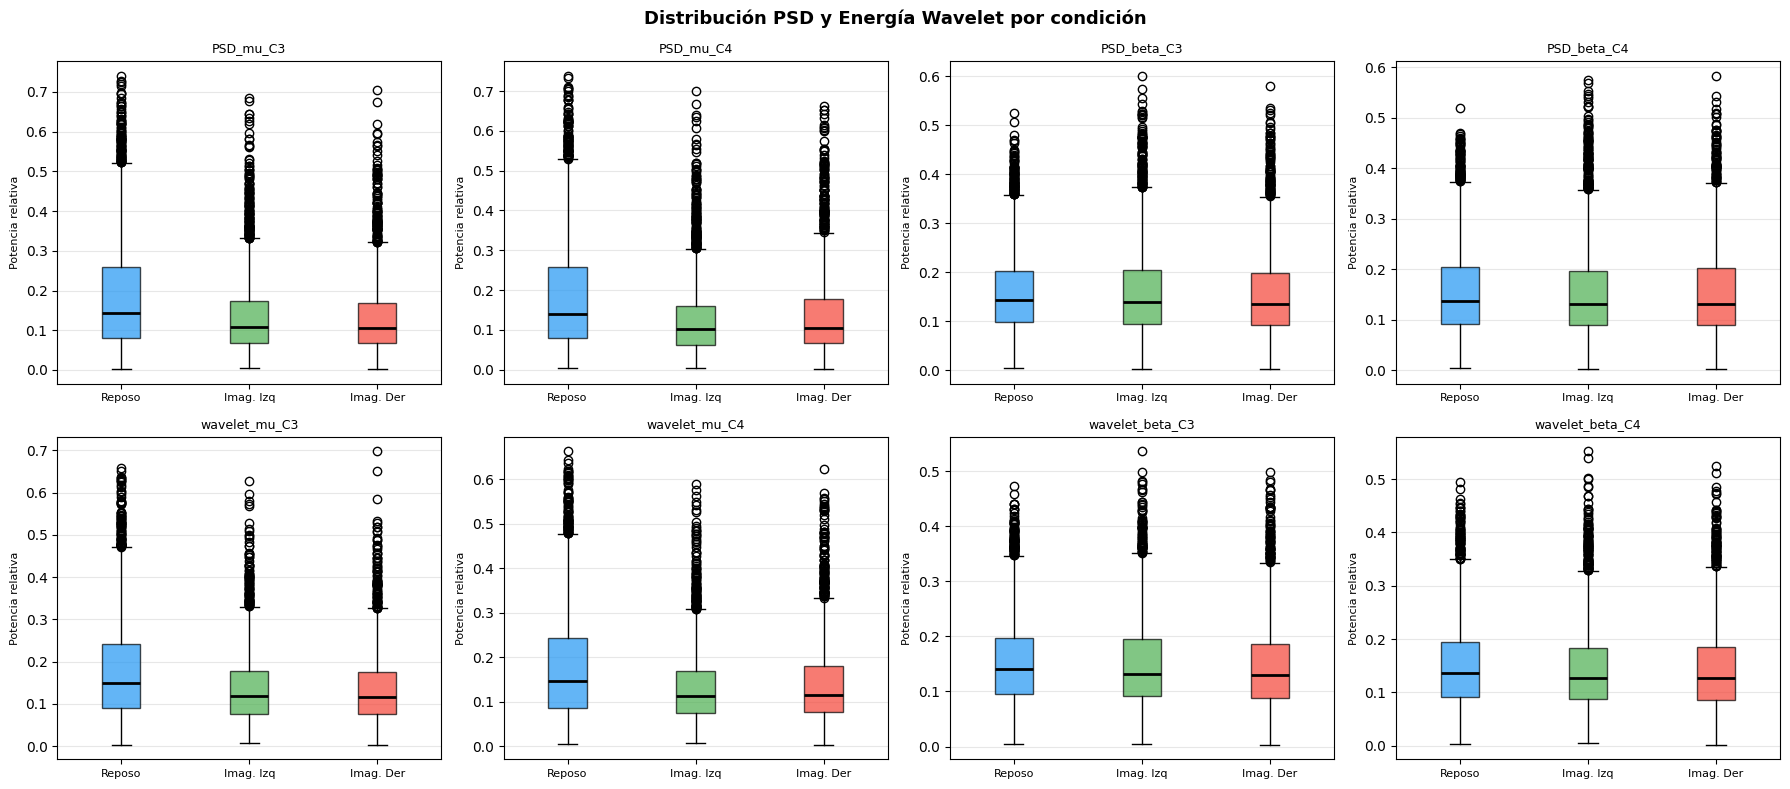

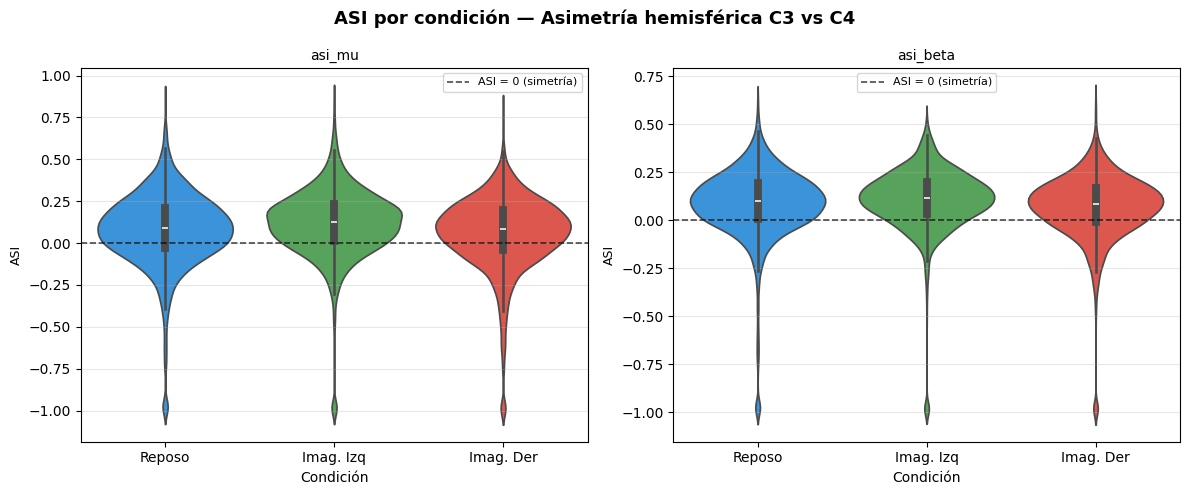

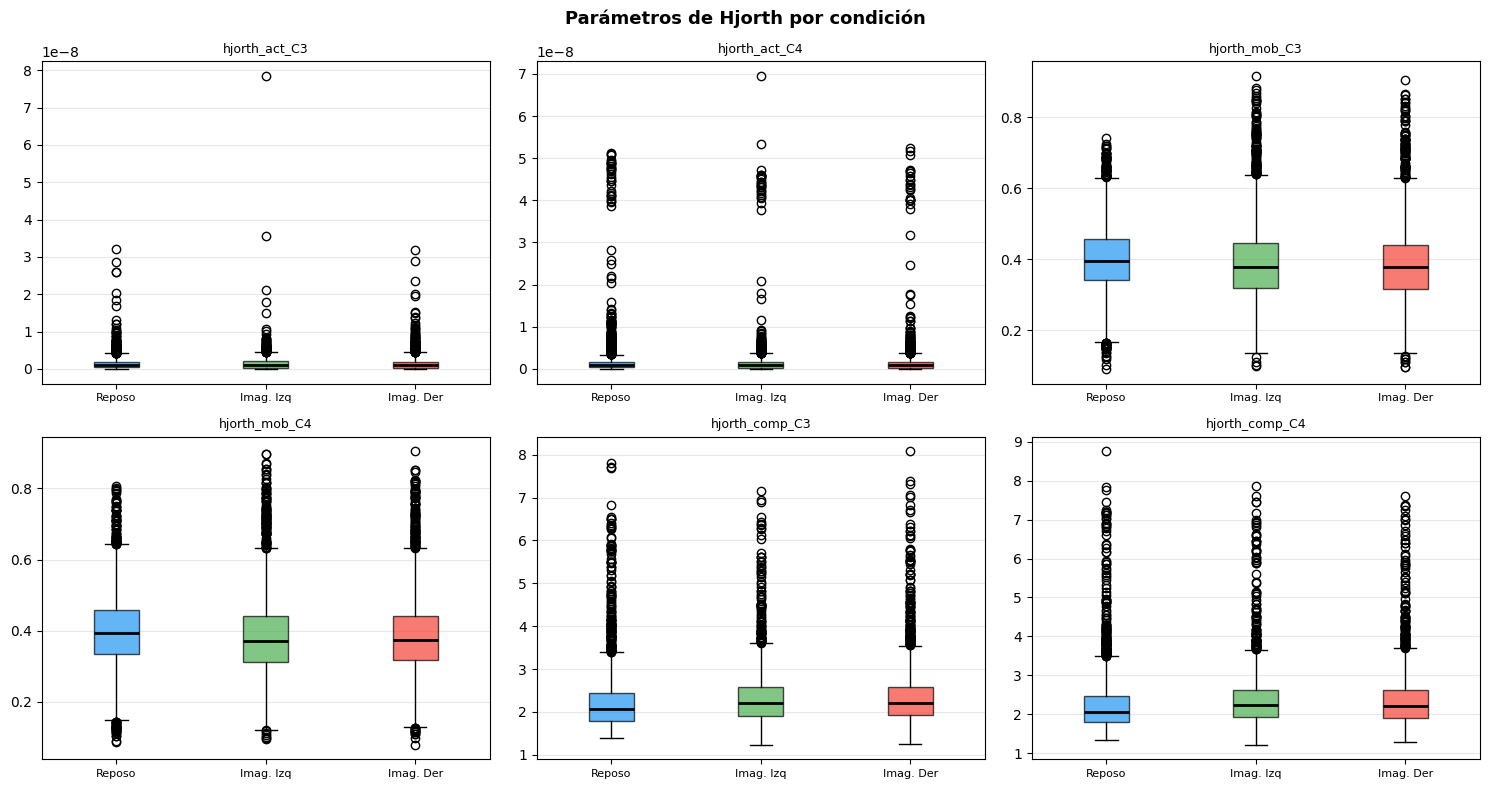

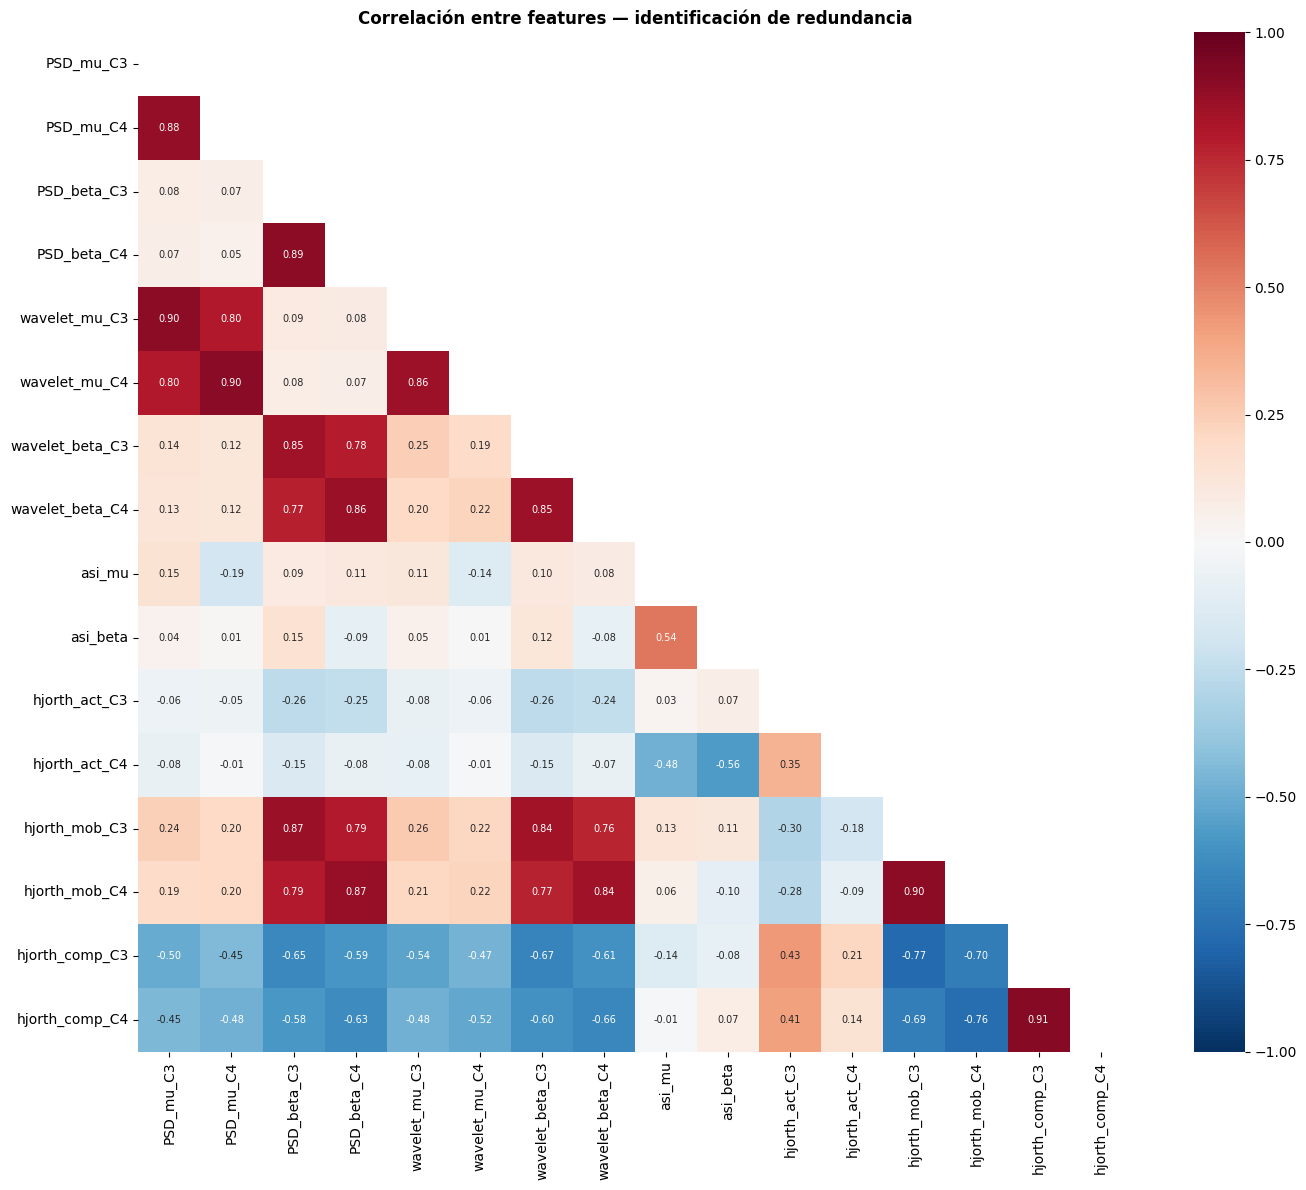


Pares con |r| ≥ 0.8
  Total encontrados: 16
      feature_1       feature_2  correlacion
 hjorth_comp_C3  hjorth_comp_C4        0.912
      PSD_mu_C4   wavelet_mu_C4        0.900
  hjorth_mob_C3   hjorth_mob_C4        0.897
      PSD_mu_C3   wavelet_mu_C3        0.896
    PSD_beta_C3     PSD_beta_C4        0.893
      PSD_mu_C3       PSD_mu_C4        0.876
    PSD_beta_C4   hjorth_mob_C4        0.871
    PSD_beta_C3   hjorth_mob_C3        0.867
    PSD_beta_C4 wavelet_beta_C4        0.862
  wavelet_mu_C3   wavelet_mu_C4        0.859
wavelet_beta_C3 wavelet_beta_C4        0.854
    PSD_beta_C3 wavelet_beta_C3        0.850
wavelet_beta_C4   hjorth_mob_C4        0.845
wavelet_beta_C3   hjorth_mob_C3        0.843
      PSD_mu_C3   wavelet_mu_C4        0.804
      PSD_mu_C4   wavelet_mu_C3        0.803

  Guardado → resultados/pares_alta_correlacion.csv


In [4]:
## a) 

import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'scikit-posthocs'], check=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
from scipy.stats import normaltest, kruskal
from scikit_posthocs import posthoc_dunn
import warnings
warnings.filterwarnings('ignore')

# Cargar DataFrame final
df = pd.read_csv('resultados/df_final_p2.csv')

FEATURES = [
    'PSD_mu_C3', 'PSD_mu_C4', 'PSD_beta_C3', 'PSD_beta_C4',
    'wavelet_mu_C3', 'wavelet_mu_C4', 'wavelet_beta_C3', 'wavelet_beta_C4',
    'asi_mu', 'asi_beta',
    'hjorth_act_C3', 'hjorth_act_C4',
    'hjorth_mob_C3', 'hjorth_mob_C4',
    'hjorth_comp_C3', 'hjorth_comp_C4'
]

ETIQUETAS = {0: 'Reposo', 1: 'Imag. Izq', 2: 'Imag. Der'}
COLORES   = {0: '#2196F3', 1: '#4CAF50', 2: '#F44336'}

os.makedirs('figuras_p2', exist_ok=True)

#   Mediana e IQR como estadísticos robustos frente a outliers, preferidos
#   sobre media porque los datos EEG tienen distribución no normal confirmada
#   por D'Agostino-Pearson. La desviación estándar se reporta adicionalmente
#   para describir la dispersión total incluyendo valores extremos.
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

# Calcular mediana e IQR por separado
resumen_med = df.groupby('tarea')[FEATURES].median()
resumen_iqr = df.groupby('tarea')[FEATURES].agg(iqr)
resumen_med.index = resumen_med.index.map(ETIQUETAS)
resumen_iqr.index = resumen_iqr.index.map(ETIQUETAS)
print(' Mediana por condición')
print(resumen_med.round(4))
print('\n IQR por condición')
print(resumen_iqr.round(4))
resumen_med.to_csv('resultados/resumen_mediana.csv')
resumen_iqr.to_csv('resultados/resumen_iqr.csv')


# Figura 1: Boxplots PSD y Wavelet 
# Comparación de distribuciones por condición para los grupos PSD y Wavelet.
# Boxplot elegido por su capacidad de mostrar mediana, cuartiles y outliers
# simultáneamente para comparaciones entre tres grupos.

features_psd_wav = [
    'PSD_mu_C3', 'PSD_mu_C4', 'PSD_beta_C3', 'PSD_beta_C4',
    'wavelet_mu_C3', 'wavelet_mu_C4', 'wavelet_beta_C3', 'wavelet_beta_C4'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distribución PSD y Energía Wavelet por condición',
             fontsize=13, fontweight='bold')
for ax, feat in zip(axes.flat, features_psd_wav):    # Cada feature en su plot
    datos = [df[df['tarea'] == t][feat].values for t in [0, 1, 2]] # Valores del feature para cadacondicón
    bp    = ax.boxplot(datos, patch_artist=True, notch=False,
                       medianprops=dict(color='black', linewidth=2))
    for patch, t in zip(bp['boxes'], [0, 1, 2]):
        patch.set_facecolor(COLORES[t])
        patch.set_alpha(0.7)
    ax.set_xticklabels([ETIQUETAS[t] for t in [0, 1, 2]], fontsize=8)
    ax.set_title(feat, fontsize=9)
    ax.set_ylabel('Potencia relativa', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figuras_p2/boxplot_psd_wavelet.png', dpi=120)
plt.show()
plt.close()


# Figura 2: Violin plots ASI
# Violin plot para ASI porque se espera distribución bimodal:
# valores positivos para imag_der (ERD en C3) y negativos para imag_izq
# (ERD en C4). El violin muestra esta forma mejor que el boxplot.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('ASI por condición — Asimetría hemisférica C3 vs C4',
             fontsize=13, fontweight='bold')

for ax, feat in zip(axes, ['asi_mu', 'asi_beta']):
    df_plot = df[['tarea', feat]].copy()
    df_plot['Condición'] = df_plot['tarea'].map(ETIQUETAS)

    sns.violinplot(data=df_plot, x='Condición', y=feat,
               order=['Reposo', 'Imag. Izq', 'Imag. Der'], 
               palette={'Reposo': '#2196F3',
                        'Imag. Izq': '#4CAF50',
                        'Imag. Der': '#F44336'},       
               inner='box', ax=ax)
    ax.axhline(0, color='black', lw=1.2, ls='--', alpha=0.7,
               label='ASI = 0 (simetría)')
    ax.set_title(feat, fontsize=10)
    ax.set_ylabel('ASI', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figuras_p2/violin_asi.png', dpi=120)
plt.show()
plt.close()


# Figura 3: Boxplots Hjorth 
features_hjorth = [
    'hjorth_act_C3', 'hjorth_act_C4',
    'hjorth_mob_C3', 'hjorth_mob_C4',
    'hjorth_comp_C3', 'hjorth_comp_C4'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Parámetros de Hjorth por condición',
             fontsize=13, fontweight='bold')

for ax, feat in zip(axes.flat, features_hjorth):
    datos = [df[df['tarea'] == t][feat].values for t in [0, 1, 2]]
    bp    = ax.boxplot(datos, patch_artist=True,
                       medianprops=dict(color='black', linewidth=2))
    for patch, t in zip(bp['boxes'], [0, 1, 2]):
        patch.set_facecolor(COLORES[t])
        patch.set_alpha(0.7)
    ax.set_xticklabels([ETIQUETAS[t] for t in [0, 1, 2]], fontsize=8)
    ax.set_title(feat, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figuras_p2/boxplot_hjorth.png', dpi=120)
plt.show()
plt.close()


# Figura 4: Heatmap de correlación entre los 16 features 
# Identifica redundancia entre índices antes de la clasificación.
# Features con |r| > 0.9 son candidatos a eliminación.

fig, ax = plt.subplots(figsize=(14, 12))
corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # triángulo superior oculto

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, annot_kws={'size': 7})
ax.set_title('Correlación entre features — identificación de redundancia',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figuras_p2/heatmap_correlacion.png', dpi=120)
plt.show()
plt.close()

# Identificación de features con correlación alta (|r| > 0.8) 
# Extrae pares de features con correlación absoluta mayor a 0.8
# para identificar redundancia antes de la clasificación.

umbral = 0.8
pares_alta_correlacion = []

for i in range(len(FEATURES)):
    for j in range(i + 1, len(FEATURES)):  # triángulo inferior, sin duplicados
        r = corr.iloc[i, j]
        if abs(r) >= umbral:
            pares_alta_correlacion.append({
                'feature_1': FEATURES[i],
                'feature_2': FEATURES[j],
                'correlacion': round(r, 3)
            })

df_pares = pd.DataFrame(pares_alta_correlacion)
df_pares = df_pares.reindex(
    df_pares['correlacion'].abs().sort_values(ascending=False).index
)

print(f'\nPares con |r| ≥ {umbral}')
print(f'  Total encontrados: {len(df_pares)}')
print(df_pares.to_string(index=False))

df_pares.to_csv('resultados/pares_alta_correlacion.csv', index=False)
print('\n  Guardado → resultados/pares_alta_correlacion.csv')



**Análisis estadístico descriptivo**
El análisis de medianas e IQR evidenció que las bandas mu y beta presentan una reducción consistente de potencia durante la imaginación motora respecto al reposo, tanto en PSD como en energía wavelet, con caídas de aproximadamente 25% en mu y 5% en beta, patrón coherente con la desincronización relacionada con eventos (ERD) reportada en la literatura. Los parámetros de Hjorth mostraron que la complejidad aumenta durante la imaginación motora (~2.20) respecto al reposo (~2.06), reflejando mayor irregularidad cortical, mientras que la movilidad disminuye levemente. La actividad de Hjorth opera en escala 1e-8 V² con mediana cercana a cero, lo que limita su interpretabilidad directa aunque puede aportar tras normalización. El ASI mostró valores positivos en todas las condiciones con diferencias entre manos, sugiriendo un sesgo sistemático de mayor potencia en C3 respecto a C4 en este dataset, aunque la diferencia relativa entre imaginación izquierda y derecha sigue siendo informativa para el clasificador.

El análisis de correlación identificó 16 pares con |r| ≥ 0.8, agrupados en tres patrones de redundancia: PSD_mu y wavelet_mu son intercambiables en ambos canales (r ≈ 0.90), PSD_beta, wavelet_beta y hjorth_movilidad capturan esencialmente la misma información de frecuencia dominante (r ≈ 0.85–0.87), y los pares C3/C4 del mismo índice son altamente redundantes (r ≈ 0.86–0.91). Con base en esto se seleccionaron 10 features para clasificación, eliminando PSD (redundante con wavelet) y hjorth_movilidad (redundante con wavelet_beta), preservando la información de lateralización en los pares C3/C4 por su relevancia neurofisiológica para discriminar mano izquierda de mano derecha.

In [5]:
# Análisis exclusivo de IM izquierda y derecha
# Paso 1: Verificación de normalidad (D'Agostino-Pearson) 
# Combina asimetría (skewness) y curtosis en un estadístico chi-cuadrado.
# Válido para cualquier n, usa todas las muestras disponibles por condición.
print('\n Paso 1: Verificación de normalidad (D\'Agostino-Pearson) ')
print('   Usa todas las muestras, combina asimetría y curtosis\n')
normalidad = {}

for feat in FEATURES:
    normal_todas = True
    for t in [0, 1, 2]:
        datos   = df[df['tarea'] == t][feat].values
        stat, p = normaltest(datos)
        if p <= 0.05:
            normal_todas = False
    normalidad[feat] = normal_todas

n_normales    = sum(normalidad.values())
n_no_normales = len(FEATURES) - n_normales
print(f'  Features con distribución normal    : {n_normales}')
print(f'  Features con distribución no normal : {n_no_normales}')
print(f'  → Prueba seleccionada: pruebas no paramétricas')


# Paso 2a: Kruskal-Wallis (3 condiciones) 
# Propósito: verificar que los features detectan diferencias generales entre
# reposo e imaginación motora. Confirma el ERD neurofisiológico esperado.
# No es el criterio principal para selección de features del clasificador.
print('\nPaso 2a: Kruskal-Wallis (reposo vs imag_izq vs imag_der)')

resultados_kw  = {}
resultados_dunn = {}

for feat in FEATURES:
    grupos = [df[df['tarea'] == t][feat].values for t in [0, 1, 2]]
    stat_kw, p_kw = kruskal(*grupos)
    resultados_kw[feat] = {'statistic': stat_kw, 'p_value': p_kw,
                           'significativo': p_kw < 0.05}

    if p_kw < 0.05:
        df_dunn = df[df['tarea'].isin([0, 1, 2])][[feat, 'tarea']].copy()
        dunn    = posthoc_dunn(df_dunn, val_col=feat, group_col='tarea',
                               p_adjust='bonferroni')
        resultados_dunn[feat] = dunn

df_kw = pd.DataFrame(resultados_kw).T
df_kw.index.name = 'feature'
df_kw = df_kw.sort_values('p_value')
df_kw.to_csv('resultados/kruskal_wallis.csv')

print(f'  Features significativos (p < 0.05): '
      f'{df_kw["significativo"].sum()} / {len(FEATURES)}')
print(df_kw[['statistic', 'p_value', 'significativo']].round(4))

# Guardar post-hoc Dunn
with open('resultados/dunn_posthoc.txt', 'w') as f:
    for feat, dunn in resultados_dunn.items():
        dunn.index   = dunn.index.map(ETIQUETAS)
        dunn.columns = dunn.columns.map(ETIQUETAS)
        f.write(f'\n{feat}:\n')
        f.write(dunn.round(4).to_string())
        f.write('\n')
print('  Post-hoc Dunn guardado → resultados/dunn_posthoc.txt')


# Paso 2b: Mann-Whitney U (Imag. Izq vs Imag. Der) 
# Propósito: pregunta clave para BCI — ¿qué features distinguen entre las
# dos manos? Solo estos features significativos entran al clasificador.
from scipy.stats import mannwhitneyu

print('\n Paso 2b: Mann-Whitney U: Imag. Izq vs Imag. Der')
print('   Pregunta clave para BCI: ¿el índice distingue entre las dos manos?\n')

df_izq = df[df['tarea'] == 1]
df_der = df[df['tarea'] == 2]

resultados_mw = {}
for feat in FEATURES:
    stat, p = mannwhitneyu(df_izq[feat].values,
                           df_der[feat].values,
                           alternative='two-sided')
    resultados_mw[feat] = {'statistic': stat, 'p_value': round(p, 6),
                           'significativo': p < 0.05}

df_mw = pd.DataFrame(resultados_mw).T
df_mw.index.name = 'feature'
df_mw = df_mw.sort_values('p_value')
df_mw.to_csv('resultados/mannwhitney_izq_vs_der.csv')

print(f'  Features significativos (p < 0.05): '
      f'{df_mw["significativo"].sum()} / {len(FEATURES)}')
print('\n  Ranking por significancia:')
print(df_mw[['statistic', 'p_value', 'significativo']].to_string())



 Paso 1: Verificación de normalidad (D'Agostino-Pearson) 
   Usa todas las muestras, combina asimetría y curtosis

  Features con distribución normal    : 0
  Features con distribución no normal : 16
  → Prueba seleccionada: pruebas no paramétricas

Paso 2a: Kruskal-Wallis (reposo vs imag_izq vs imag_der)
  Features significativos (p < 0.05): True / 16
                  statistic   p_value significativo
feature                                            
PSD_mu_C4        271.112265       0.0          True
PSD_mu_C3        266.876655       0.0          True
wavelet_mu_C3    228.145075       0.0          True
wavelet_mu_C4    223.698522       0.0          True
hjorth_comp_C3   152.691669       0.0          True
hjorth_comp_C4   139.342342       0.0          True
asi_mu           103.118626       0.0          True
asi_beta          78.182583       0.0          True
hjorth_act_C3     62.030356       0.0          True
hjorth_act_C4     58.917482       0.0          True
hjorth_mob_C3     55

**Análisis de hipótesis y resultados de indicadores para clasificación**
Los 16 features fueron no normales (D'Agostino-Pearson, p < 0.05), justificando
el uso de pruebas no paramétricas. Kruskal-Wallis confirmó que 15/16 features
detectan diferencias generales entre reposo e imaginación motora, validando el
ERD neurofisiológico esperado. Sin embargo, dado que el reposo es la condición
más fácil de discriminar, el criterio principal de selección fue Mann-Whitney U
entre imaginación izquierda y derecha, donde solo asi_mu, asi_beta y wavelet_mu_C4
resultaron significativos (p < 0.05), reflejando la organización contralateral
del sistema motor. Se complementaron con hjorth_comp_C3 y hjorth_comp_C4 por su
alto estadístico H en Kruskal-Wallis y baja correlación con los features anteriores,
descartando features redundantes con correlación mayor a 0.8. El conjunto final
de 5 features busca capturar tanto la lateralización entre manos como las
diferencias generales entre reposo e imaginación.

# **CLASIFICACIÓN**
Todos los puntos realizados a continuación son con las índices que muestren mayor 
diferencia entre las condiciones

a. Código y discusión de una estrategia de entrenamiento basada en k-fold (5%)

b. Código y análisis de resultados, donde se discutan por los menos tres diferentes 
arquitecturas de red (5%) y las matrices de confusión obtenidas (5%), para la 
clasificación de las diferentes condiciones

c. Consultar cómo funciona, realizar y discutir un ejemplo con los datos del algoritmo 
máquina de soporte vectorial (5%) y extreme gradient boosting (5%)

# Punto a yb

Se separan los datos por el métido pedido K-fold y staterfieldKfold, de una vez se aplica un modelo de MLP para ver los resultados de desempeño.

Features: 5
['asi_mu', 'asi_beta', 'wavelet_mu_C4', 'hjorth_comp_C3', 'hjorth_comp_C4']
Shape X: (8079, 5)
 INICIANDO ENTRENAMIENTO: Arq.1 (4,) — K-Fold estándar
Fold 1:
  -> TRAIN | Accuracy: 0.4320 | F1 Macro: 0.4103
  -> TEST  | Accuracy: 0.4103  | F1 Macro: 0.3920
Fold 2:
  -> TRAIN | Accuracy: 0.4286 | F1 Macro: 0.4107
  -> TEST  | Accuracy: 0.4202  | F1 Macro: 0.4060
Fold 3:
  -> TRAIN | Accuracy: 0.4280 | F1 Macro: 0.4110
  -> TEST  | Accuracy: 0.4165  | F1 Macro: 0.3990
Fold 4:
  -> TRAIN | Accuracy: 0.4264 | F1 Macro: 0.4042
  -> TEST  | Accuracy: 0.4288  | F1 Macro: 0.4100
Fold 5:
  -> TRAIN | Accuracy: 0.4233 | F1 Macro: 0.4032
  -> TEST  | Accuracy: 0.4483  | F1 Macro: 0.4190
RESUMEN PROMEDIO 5 FOLDS: Arq.1 (4,) — K-Fold estándar
TRAIN | Accuracy: 0.4277 | F1 Macro: 0.4079
TEST  | Accuracy: 0.4248  | F1 Macro: 0.4052

CLASSIFICATION REPORT: TRAIN:
               precision    recall  f1-score   support

   Reposo (0)       0.48      0.58      0.52     12960
Imag. Izq (1)    

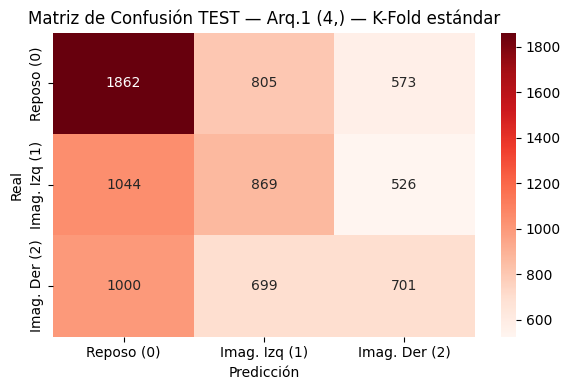

 INICIANDO ENTRENAMIENTO: Arq.1 (4,) — Stratified K-Fold
Fold 1:
  -> TRAIN | Accuracy: 0.4283 | F1 Macro: 0.4105
  -> TEST  | Accuracy: 0.4325  | F1 Macro: 0.4147
Fold 2:
  -> TRAIN | Accuracy: 0.4328 | F1 Macro: 0.4119
  -> TEST  | Accuracy: 0.4152  | F1 Macro: 0.3926
Fold 3:
  -> TRAIN | Accuracy: 0.4314 | F1 Macro: 0.4159
  -> TEST  | Accuracy: 0.4165  | F1 Macro: 0.3936
Fold 4:
  -> TRAIN | Accuracy: 0.4286 | F1 Macro: 0.4067
  -> TEST  | Accuracy: 0.4319  | F1 Macro: 0.4130
Fold 5:
  -> TRAIN | Accuracy: 0.4220 | F1 Macro: 0.3989
  -> TEST  | Accuracy: 0.4310  | F1 Macro: 0.4128
RESUMEN PROMEDIO 5 FOLDS: Arq.1 (4,) — Stratified K-Fold
TRAIN | Accuracy: 0.4286 | F1 Macro: 0.4088
TEST  | Accuracy: 0.4254  | F1 Macro: 0.4053

CLASSIFICATION REPORT: TRAIN:
               precision    recall  f1-score   support

   Reposo (0)       0.48      0.58      0.53     12960
Imag. Izq (1)       0.37      0.36      0.37      9756
Imag. Der (2)       0.39      0.30      0.34      9600

     accu

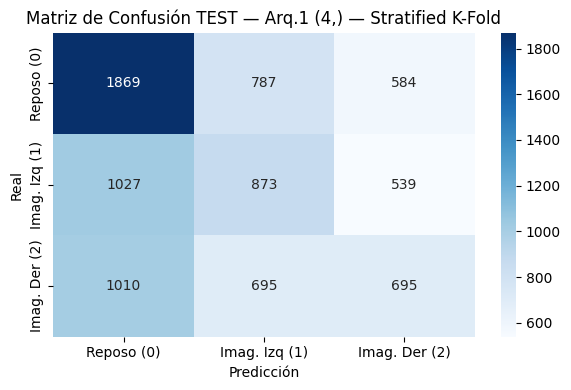

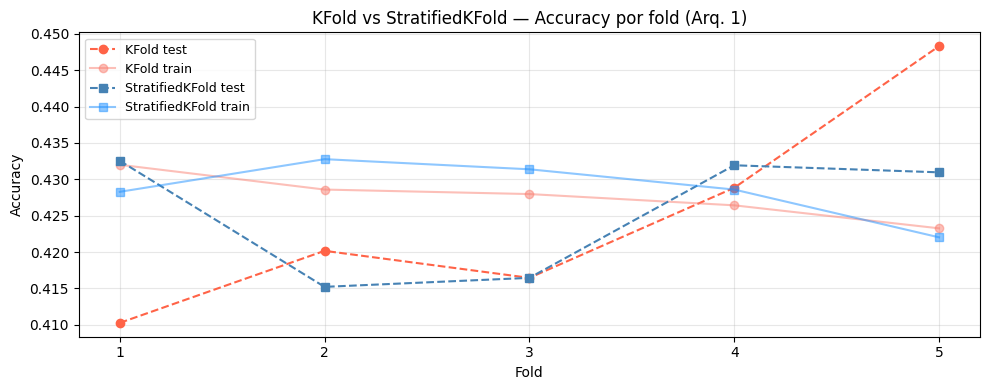

 INICIANDO ENTRENAMIENTO: Arquitectura 2 (6,) — Regla 2
Fold 1:
  -> TRAIN | Accuracy: 0.4222 | F1 Macro: 0.3970
  -> TEST  | Accuracy: 0.4177  | F1 Macro: 0.3930
Fold 2:
  -> TRAIN | Accuracy: 0.4284 | F1 Macro: 0.3942
  -> TEST  | Accuracy: 0.4307  | F1 Macro: 0.4015
Fold 3:
  -> TRAIN | Accuracy: 0.4312 | F1 Macro: 0.4079
  -> TEST  | Accuracy: 0.4053  | F1 Macro: 0.3743
Fold 4:
  -> TRAIN | Accuracy: 0.4312 | F1 Macro: 0.3920
  -> TEST  | Accuracy: 0.4165  | F1 Macro: 0.3792
Fold 5:
  -> TRAIN | Accuracy: 0.4240 | F1 Macro: 0.3854
  -> TEST  | Accuracy: 0.4334  | F1 Macro: 0.3992
RESUMEN PROMEDIO 5 FOLDS: Arquitectura 2 (6,) — Regla 2
TRAIN | Accuracy: 0.4274 | F1 Macro: 0.3953
TEST  | Accuracy: 0.4207  | F1 Macro: 0.3894

CLASSIFICATION REPORT: TRAIN:
               precision    recall  f1-score   support

   Reposo (0)       0.47      0.63      0.54     12960
Imag. Izq (1)       0.39      0.37      0.38      9756
Imag. Der (2)       0.37      0.22      0.27      9600

     accura

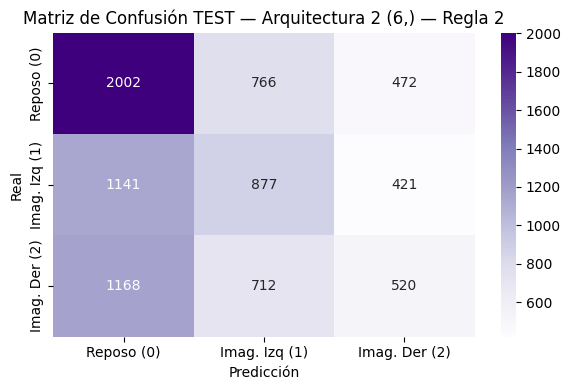

 INICIANDO ENTRENAMIENTO: Arquitectura 3 (8,) — Regla 3
Fold 1:
  -> TRAIN | Accuracy: 0.4334 | F1 Macro: 0.4048
  -> TEST  | Accuracy: 0.4431  | F1 Macro: 0.4119
Fold 2:
  -> TRAIN | Accuracy: 0.4407 | F1 Macro: 0.4247
  -> TEST  | Accuracy: 0.4171  | F1 Macro: 0.4020
Fold 3:
  -> TRAIN | Accuracy: 0.4312 | F1 Macro: 0.4170
  -> TEST  | Accuracy: 0.4090  | F1 Macro: 0.3869
Fold 4:
  -> TRAIN | Accuracy: 0.4270 | F1 Macro: 0.3950
  -> TEST  | Accuracy: 0.4214  | F1 Macro: 0.3959
Fold 5:
  -> TRAIN | Accuracy: 0.4244 | F1 Macro: 0.4063
  -> TEST  | Accuracy: 0.4464  | F1 Macro: 0.4312
RESUMEN PROMEDIO 5 FOLDS: Arquitectura 3 (8,) — Regla 3
TRAIN | Accuracy: 0.4313 | F1 Macro: 0.4096
TEST  | Accuracy: 0.4274  | F1 Macro: 0.4056

CLASSIFICATION REPORT: TRAIN:
               precision    recall  f1-score   support

   Reposo (0)       0.49      0.57      0.53     12960
Imag. Izq (1)       0.37      0.42      0.39      9756
Imag. Der (2)       0.40      0.26      0.31      9600

     accura

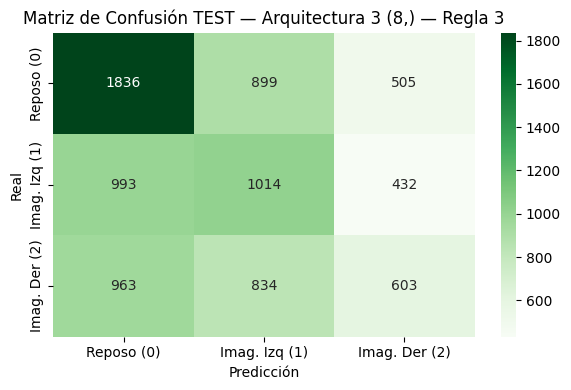


Tabla comparativa de arquitecturas (StratifiedKFold)
                               Acc TRAIN  F1 TRAIN  Acc TEST  F1 TEST
Arquitectura 1 (4,) — Regla 1     0.4286    0.4088    0.4254   0.4053
Arquitectura 2 (6,) — Regla 2     0.4274    0.3953    0.4207   0.3894
Arquitectura 3 (8,) — Regla 3     0.4313    0.4096    0.4274   0.4056


In [23]:
import seaborn as sns
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier


# Seleccionamos los índices de acuerdo al análisis estadístico
features_ganadoras = [
    'asi_mu', 'asi_beta',
    'wavelet_mu_C4',   
    'hjorth_comp_C3',
    'hjorth_comp_C4'
]

#Extraemos las matrices de características (X) y las etiquetas/clases a predecir (y)
X = df_final[features_ganadoras].values
y = df_final['tarea'].values
nombres_clases = ['Reposo (0)', 'Imag. Izq (1)', 'Imag. Der (2)']

print(f'Features: {len(features_ganadoras)}')
print(features_ganadoras)
print(f'Shape X: {X.shape}') 

def entrenar_y_evaluar(X, y, kfold, arquitectura, nombre, color_cm, nombres_clases):
    """
    Entrena MLP con la arquitectura dada usando la estrategia de particionamiento
    recibida. Reporta métricas de TRAIN y TEST por fold y globales.

    Retorna
    -------
    acc_train_mean, f1_train_mean, acc_test_mean, f1_test_mean : float
        Promedios sobre los 5 folds
    acc_train_list, acc_test_list : list
        Accuracy por fold para comparación gráfica
    """
    acc_train_list, f1_train_list = [], []
    acc_test_list,  f1_test_list  = [], []
    y_true_train_all, y_pred_train_all = [], []
    y_true_test_all,  y_pred_test_all  = [], []

    print(f' INICIANDO ENTRENAMIENTO: {nombre}')

    # LÍNEA CLAVE: Verifica si el objeto kfold es estratificado (requiere X e y para equilibrar clases) 
    # o si es KFold normal (solo requiere X). Lo usamos para el punto a
    split = kfold.split(X, y) if isinstance(kfold, StratifiedKFold) else kfold.split(X)

    for fold, (train_idx, test_idx) in enumerate(split):
        #Separación estricta de datos para evitar Data Leakage (fuga de información)
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        #El escalado (normalización) se ajusta SOLO con los datos de entrenamiento (fit_transform)
        # y luego se aplica a los de prueba (transform)
        scaler         = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled  = scaler.transform(X_test)

        modelo = MLPClassifier(hidden_layer_sizes=arquitectura,
                               max_iter=1000, random_state=42)
        modelo.fit(X_train_scaled, y_train)

        # TRAIN
        y_pred_train = modelo.predict(X_train_scaled)
        acc_train    = accuracy_score(y_train, y_pred_train)
        f1_train     = f1_score(y_train, y_pred_train, average='macro')
        acc_train_list.append(acc_train)
        f1_train_list.append(f1_train)
        y_true_train_all.extend(y_train)
        y_pred_train_all.extend(y_pred_train)

        # TEST
        y_pred_test = modelo.predict(X_test_scaled)
        acc_test    = accuracy_score(y_test, y_pred_test)
        f1_test     = f1_score(y_test, y_pred_test, average='macro')
        acc_test_list.append(acc_test)
        f1_test_list.append(f1_test)
        y_true_test_all.extend(y_test)
        y_pred_test_all.extend(y_pred_test)

        print(f'Fold {fold+1}:')
        print(f'  -> TRAIN | Accuracy: {acc_train:.4f} | F1 Macro: {f1_train:.4f}')
        print(f'  -> TEST  | Accuracy: {acc_test:.4f}  | F1 Macro: {f1_test:.4f}')

    print(f'RESUMEN PROMEDIO 5 FOLDS: {nombre}')
    print(f'TRAIN | Accuracy: {np.mean(acc_train_list):.4f} | F1 Macro: {np.mean(f1_train_list):.4f}')
    print(f'TEST  | Accuracy: {np.mean(acc_test_list):.4f}  | F1 Macro: {np.mean(f1_test_list):.4f}')
    print(f'{"="*50}')

    print('\nCLASSIFICATION REPORT: TRAIN:')
    print(classification_report(y_true_train_all, y_pred_train_all, target_names=nombres_clases))
    print('\nCLASSIFICATION REPORT: TEST:')
    print(classification_report(y_true_test_all, y_pred_test_all, target_names=nombres_clases))

    print('\nDiagnóstico de fit por fold:')
    for i, (tr, te) in enumerate(zip(acc_train_list, acc_test_list)):
        gap = tr - te
        if gap < 0.05:
            diag = 'Good fit ✓'
        elif gap < 0.15:
            diag = 'Leve overfitting ⚠'
        else:
            diag = 'Overfitting ✗'
        print(f'  Fold {i+1}: train={tr:.4f} | test={te:.4f} | gap={gap:.4f} → {diag}')

    # Matriz de confusión TEST
    cm = confusion_matrix(y_true_test_all, y_pred_test_all)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=color_cm,
                xticklabels=nombres_clases, yticklabels=nombres_clases)
    plt.title(f'Matriz de Confusión TEST — {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

    return (np.mean(acc_train_list), np.mean(f1_train_list),
            np.mean(acc_test_list),  np.mean(f1_test_list),
            acc_train_list, acc_test_list)  # ← listas por fold


# Punto a): KFold vs StratifiedKFold con Arq. 1 
kf  = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

_, _, _, _, acc_train_kf, acc_test_kf = entrenar_y_evaluar(
    X, y, kf,  (4,), 'Arq.1 (4,) — K-Fold estándar',   'Reds',  nombres_clases)
acc_tr_arq1, f1_tr_arq1, acc_te_arq1, f1_te_arq1, acc_train_skf, acc_test_skf = entrenar_y_evaluar(
    X, y, skf, (4,), 'Arq.1 (4,) — Stratified K-Fold', 'Blues', nombres_clases)


# Gráfica comparativa KFold vs StratifiedKFold
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(1, 6)
ax.plot(x, acc_test_kf,   'o--', color='tomato',     label='KFold test')
ax.plot(x, acc_train_kf,  'o-',  color='salmon',     label='KFold train',           alpha=0.5)
ax.plot(x, acc_test_skf,  's--', color='steelblue',  label='StratifiedKFold test')
ax.plot(x, acc_train_skf, 's-',  color='dodgerblue', label='StratifiedKFold train', alpha=0.5)
ax.set_xticks(x)
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('KFold vs StratifiedKFold — Accuracy por fold (Arq. 1)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('resultados/clasificacion/kfold_vs_stratified.png', dpi=120)
plt.show()


# Punto b): comparación de 2 arquitecturas con StratifiedKFold 
# Se usa StratifiedKFold en todas las arquitecturas porque garantiza
# la proporción de clases en cada fold.
# La arquitectura 1 ya está en el punto a de comparación Kfold vs StratifiedKfold
arquitecturas = {
    'Arquitectura 2 (6,) — Regla 2': (6,),
    'Arquitectura 3 (8,) — Regla 3': (8,),
}
colores = ['Purples', 'Greens']

resumen = {
    'Arquitectura 1 (4,) — Regla 1': {
        'Acc TRAIN': acc_tr_arq1,   # ← guardar estos valores en el punto a
        'F1 TRAIN' : f1_tr_arq1,
        'Acc TEST' : acc_te_arq1,
        'F1 TEST'  : f1_te_arq1
    }
}
for (nombre, capas), color in zip(arquitecturas.items(), colores):
    acc_tr, f1_tr, acc_te, f1_te, _, _ = entrenar_y_evaluar(
        X, y, skf, capas, nombre, color, nombres_clases)
    resumen[nombre] = {'Acc TRAIN': acc_tr, 'F1 TRAIN': f1_tr,
                       'Acc TEST' : acc_te, 'F1 TEST' : f1_te}

# ── Tabla comparativa final ───────────────────────────────────────────────────
print('\nTabla comparativa de arquitecturas (StratifiedKFold)')
df_resumen = pd.DataFrame(resumen).T.round(4)
print(df_resumen)

## **Análisis estrategia de particionamiento: KFold vs StratifiedKFold**

Se evaluaron dos estrategias de particionamiento sobre la Arquitectura 1
(capa oculta de 4 neuronas) para seleccionar la más adecuada dado el
desbalance de clases del dataset (Reposo: 3240, Imag. Izq: 2439, Imag. Der: 2400).


Los resultados fueron: 

| Métrica | KFold | StratifiedKFold |
|---------|-------|----------------|
| Accuracy TEST promedio | 0.4248 | 0.4254 |
| F1 Macro TEST promedio | 0.4052 | 0.4053 |
| Rango accuracy TEST | 0.410 – 0.448 | 0.415 – 0.433 |
| Diagnóstico fit | Good fit ✓ (5/5) | Good fit ✓ (5/5) |

Ambas estrategias producen accuracy y F1 macro (promedio de los folds) prácticamente idénticos
(~0.425 y ~0.405 respectivamente), con diagnóstico de good fit en todos
los folds debido a los gaps mínimos entre train y test (menores a 0.025
en ambos casos).

Sin embargo, la gráfica comparativa revela la diferencia relevante entre ambas
estrategias. KFold muestra una tendencia creciente sostenida en el
accuracy de test, pasando de 0.410 en el fold 1 hasta 0.448 en el fold 5,
un rango de 0.038 puntos. Esta variabilidad indica que el rendimiento
depende de cómo queden distribuidas las clases en cada partición aleatoria,
lo cual es un efecto del desbalance entre condiciones. StratifiedKFold en
cambio mantiene el accuracy de test entre 0.415 y 0.433, un rango de solo
0.018 puntos, con una curva visualmente más estable. Esto confirma que al garantizar la proporción de
clases en cada fold las estimaciones son más reproducibles y representativas
del rendimiento real del modelo, por lo cual usaremos para el punto b) esta estrategia de partición de datos.


## **Análisis de las tres arquitecturas de red**

Las tres arquitecturas fueron diseñadas siguiendo las reglas heurísticas
para redes MLP con 5 features de entrada y 3 clases de salida:

| Arquitectura | Capas ocultas | Regla aplicada | Justificación |
|---|---|---|---|
| Arq. 1 | (4,) | Regla 1 | Neuronas entre salida (3) y entrada (5) |
| Arq. 2 | (6,) | Regla 2 | 2/3 × entradas + salidas = 2/3×6 + 3 ≈ 6,3 → 6 |
| Arq. 3 | (8,) | Regla 3 | Menos del doble de entradas = menos de 10 → 8 |

### Resultados comparativos

| Métrica | Arq. 1 (4,) | Arq. 2 (6,) | Arq. 3 (8,) |
|---------|------------|------------|------------|
| Acc TRAIN | 0.4286 | 0.4274 | 0.4313 |
| F1 TRAIN | 0.4088 | 0.3953 | 0.4096 |
| Acc TEST | 0.4254 | 0.4207 | 0.4274 |
| F1 TEST | 0.4053 | 0.3894 | 0.4056 |
| Diagnóstico | Good fit ✓ (5/5) | Good fit ✓ (5/5) | Good fit ✓ (5/5) |

### Análisis por arquitectura

**Arquitectura 1 (4 neuronas):**
Accuracy TEST de 0.4254 y F1 macro de 0.4053 para test. Es la arquitectura más
simple y muestra buen equilibrio entre las tres clases en el classification
report (Reposo f1=0.52, Imag. Izq f1=0.36, Imag. Der f1=0.33). Los gaps
entre train y test son mínimos en todos los folds, con valores negativos
en algunos casos, lo que confirma ausencia de overfitting.

**Arquitectura 2 (6 neuronas):**
Accuracy TEST de 0.4207 y F1 macro de 0.3894, los valores más bajos de
las tres arquitecturas. El classification report revela el problema: Imag.
Der cae a f1=0.27 con recall de apenas 0.22, indicando que el modelo
prácticamente no detecta la clase derecha. Aunque el diagnóstico de fit
es bueno, el rendimiento general es inferior.

**Arquitectura 3 (8 neuronas):**
Accuracy TEST de 0.4274 y F1 macro de 0.4056, los mejores valores de
las tres arquitecturas. El classification report muestra la distribución
más equilibrada: Reposo f1=0.52, Imag. Izq f1=0.39, Imag. Der f1=0.31.
Aunque Imag. Der sigue siendo la clase más difícil, su f1=0.31 es mejor
que en las otras dos arquitecturas. Los gaps train-test son mínimos en
todos los folds (máximo 0.024), confirmando buena generalización.

Por lo anterior se concluye que la Arquitectura 3 (8 neuronas) es la de mejor rendimiento con Acc TEST
de 0.4274 y F1 macro de 0.4056, seguida de cerca por la Arquitectura 1.
La Arquitectura 2 es la de menor rendimiento pese a tener más neuronas
que la 1, lo que sugiere que el número óptimo de neuronas para este
problema no es necesariamente el mayor sino el que mejor equilibra la
capacidad de representación con la complejidad del problema.

El patrón común a las tres arquitecturas es la baja sensibilidad para
detectar Imag. Der (recall entre 0.22 y 0.29), indicando que el modelo
confunde sistemáticamente esta clase con las otras dos. Esto es consistente
con el análisis estadístico donde Mann-Whitney mostró baja significancia
en la discriminación izquierda vs derecha, y con los resultados del
Proyecto 1 donde la lateralización contralateral no fue robusta a nivel
poblacional en ninguno de los dos canales, atenuándose por la alta
variabilidad intersujeto.

# c)

Entrenando modelo: SVM (RBF) ...
Entrenando modelo: XGBoost ...

--- Resultados Promedio (k=5) ---


,Train_Accuracy,Test_Accuracy,Train_F1_Macro,Test_F1_Macro
SVM (RBF),0.441,0.421,0.435,0.416
XGBoost,0.581,0.426,0.568,0.406


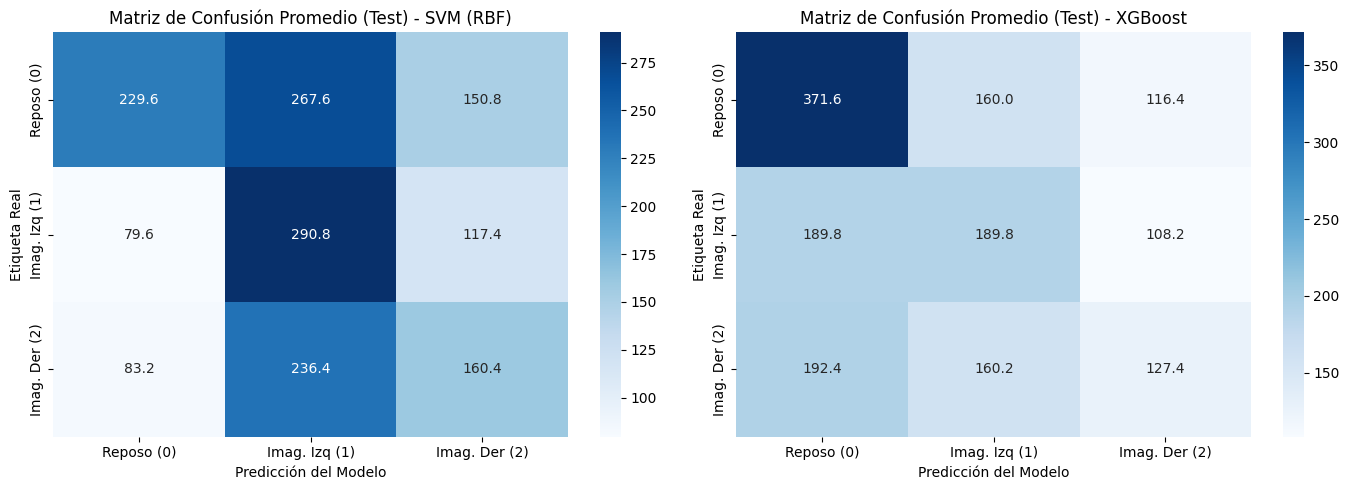

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold # Validación cruzada manteniendo proporción de clases
from sklearn.preprocessing import StandardScaler # Escalado de datos (media=0, desviación=1)
from sklearn.svm import SVC # Modelo de Máquina de Soporte Vectorial (SVM)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix # Métricas de evaluación
from xgboost import XGBClassifier  # Modelo de clasificación basado en gradient boosting


#CONFIGURACIÓN GENERAL Y MODELOS

# Crea el objeto de validación cruzada estratificada con 5 particiones, mezclando los datos aleatoriamente con semilla fija para reproducibilidad
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Se definen dos modelos con parámetros recomendados para este tipo de datos


#Define el modelo SVM con kernel RBF (no lineal), regularización C=1.0, gamma automático y pesos balanceados por clase para datos desbalanceados
modelo_svm = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42)


# Define el modelo XGBoost para clasificación multiclase con 3 clases, profundidad máxima de árbol 4, tasa de aprendizaje 0.1, 100 árboles de decision, submuestreo del 80% por árbol
#XGBoost no usa un solo árbol, sino que construye 100 árboles en secuencia, donde cada árbol nuevo intenta corregir los errores del anterior. A eso se le llama gradient boosting.

modelo_xgb = XGBClassifier(
    objective='multi:softmax', 
    num_class=3,  # Número de clases a predecir
    eval_metric='mlogloss',
    max_depth=4,  #La profundidad máxima de 4 significa que ese árbol puede hacer hasta 4 niveles de preguntas antes de dar una respuesta.
    learning_rate=0.1,  # Tasa de aprendizaje (paso de actualización)
    n_estimators=100, #Numero total de arboles a construir
    subsample=0.8,  # Fracción de muestras usadas por árbol (evita sobreajuste)
    random_state=42  # Semilla para reproducibilidad
)

modelos = {'SVM (RBF)': modelo_svm, 'XGBoost': modelo_xgb} # Diccionario que agrupa ambos modelos   
resultados_métricas = {}  # Diccionario vacío donde se guardarán las métricas de cada modelo
matrices_confusion = {} # Diccionario vacío donde se guardarán las matrices de confusión


# ENTRENAMIENTO Y EVALUACIÓN CON VALIDACIÓN CRUZADA ESTRATIFICADA

for nombre_modelo, modelo in modelos.items():
    print(f"Entrenando modelo: {nombre_modelo} ...")
    
    # Listas para almacenar las métricas de Entrenamiento
    train_accuracies = []
    train_f1_macros = []
    
    # Listas para almacenar las métricas de Prueba
    test_accuracies = []
    test_f1_macros = []
    
    # Matriz acumuladora para hacer el promedio al final de los 5 folds (solo de Test)
    matriz_acumulada_test = np.zeros((3, 3))
    
    for train_index, test_index in skf.split(X, y):
        # Partición de datos
        # Separa los datos de entrenamiento y prueba según los índices del fold actual, Usa .iloc si es DataFrame, o indexación directa si es array de numpy

        X_train_fold = X.iloc[train_index] if isinstance(X, pd.DataFrame) else X[train_index]
        X_test_fold  = X.iloc[test_index] if isinstance(X, pd.DataFrame) else X[test_index]
        y_train_fold = y.iloc[train_index] if isinstance(y, pd.Series) else y[train_index]
        y_test_fold  = y.iloc[test_index] if isinstance(y, pd.Series) else y[test_index]
        
        # Crea un nuevo escalador por fold para evitar fuga de información entre particiones        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold) # Aprende la escala del train y transforma
        X_test_scaled  = scaler.transform(X_test_fold) # Aplica la misma escala aprendida al test
        
        # Entrena el modelo con los datos de entrenamiento escalados del fold actual
        modelo.fit(X_train_scaled, y_train_fold)
        
        # PREDICCIONES (Aquí sacamos ambas predicciones)
        y_train_pred = modelo.predict(X_train_scaled) # Predicción de Entrenamiento
        y_test_pred = modelo.predict(X_test_scaled)   # Predicción de Prueba
        
        # Cálculo de Métricas por fold - TRAIN
        train_accuracies.append(accuracy_score(y_train_fold, y_train_pred))
        train_f1_macros.append(f1_score(y_train_fold, y_train_pred, average='macro'))
        
        # Cálculo de Métricas por fold - TEST
        test_accuracies.append(accuracy_score(y_test_fold, y_test_pred))
        test_f1_macros.append(f1_score(y_test_fold, y_test_pred, average='macro'))
        
        # Sumar a la matriz de confusión (siempre evaluamos visualmente en Test)
        matriz_acumulada_test += confusion_matrix(y_test_fold, y_test_pred, labels=[0, 1, 2])
        
    # Guarda las métricas promedio de los 5 folds para el modelo actual
    resultados_métricas[nombre_modelo] = {
        'Train_Accuracy': np.mean(train_accuracies),
        'Test_Accuracy': np.mean(test_accuracies),
        'Train_F1_Macro': np.mean(train_f1_macros),
        'Test_F1_Macro': np.mean(test_f1_macros)
    }
    # Divide la matriz acumulada entre 5 para obtener el promedio por fold
    matrices_confusion[nombre_modelo] = matriz_acumulada_test / skf.n_splits

# IMPRESIÓN DE RESULTADOS

# Convierte el diccionario de métricas a DataFrame y transpone para mejor legibilidad
df_resultados = pd.DataFrame(resultados_métricas).T
print("\n--- Resultados Promedio (k=5) ---")
display(df_resultados.round(3))

# VISUALIZACIÓN DE MATRICES DE CONFUSIÓN (SOBRE EL TEST SET)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
nombres_clases = ['Reposo (0)', 'Imag. Izq (1)', 'Imag. Der (2)']

for idx, (nombre_modelo, matriz) in enumerate(matrices_confusion.items()):
    # Dibuja el mapa de calor de la matriz de confusión promedio , annot=True muestra los valores, fmt='.1f' con 1 decimal, cmap='Blues' paleta azul

    sns.heatmap(matriz, annot=True, fmt='.1f', cmap='Blues', xticklabels=nombres_clases, yticklabels=nombres_clases, ax=axes[idx])
    axes[idx].set_title(f'Matriz de Confusión Promedio (Test) - {nombre_modelo}', fontsize=12)
    axes[idx].set_xlabel('Predicción del Modelo')
    axes[idx].set_ylabel('Etiqueta Real')

plt.tight_layout()
plt.show()

# Importancia de las características en XGBoost 
if isinstance(X, pd.DataFrame):  # Solo ejecuta si X tiene nombres de columnas (es un DataFrame)
    plt.figure(figsize=(10, 5))
    # Crea una Serie con la importancia de cada característica y las ordena de mayor a menor
    importancias = pd.Series(modelo_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
    importancias.plot(kind='bar', color='teal')
    plt.title('Importancia de las Características (XGBoost)')
    plt.ylabel('Puntuación F')
    plt.show()